# 01 土地使用資料稽核 (Data Audit)

In [1]:
import geopandas as gpd
import pandas as pd
from pathlib import Path

# 自動判斷路徑（無論工作目錄在專案根目錄還是 src/ 都可正確讀取）
base_dir = Path.cwd()
data_path = base_dir / "data" / "landuse_main" / "landuse_main.shp"
if not data_path.exists():
    data_path = base_dir.parent / "data" / "landuse_main" / "landuse_main.shp"

print(f"讀取資料路徑: {data_path.resolve()}")
landuse = gpd.read_file(data_path, encoding="cp950")
landuse = landuse.set_crs(epsg=3826)
print("資料數量與欄位：", landuse.shape)
landuse.head()

讀取資料路徑: C:\Users\RollyHe\Desktop\Project\taipei_urban_gis\data\landuse_main\landuse_main.shp
資料數量與欄位： (3840, 13)


,編號,圖層,顏色,街廓編號,分區代碼,分區簡稱,使用分區,分區說明,原屬分區,變更前代碼,變更前簡稱,變更前分區,geometry
0,1,368,0,None,細部計畫範圍,細部計畫範圍,NaN,None,None,None,None,None,"POLYGON ((294770.795 2790592.095, 319674.63 27..."
1,2,370,0,None,規劃範圍,規劃範圍,NaN,None,None,None,None,None,"POLYGON ((294770.795 2790592.095, 319674.63 27..."
2,3,370,0,None,規劃範圍,規劃範圍,NaN,None,None,None,None,None,"POLYGON ((294770.795 2790592.095, 319674.63 27..."
3,4,47,50,None,TP,國家公園,陽明山國家公園區,None,None,None,None,None,"POLYGON ((299748.236 2783740.339, 299808.257 2..."
4,5,NaN,NaN,None,NaN,NaN,NaN,None,None,None,None,None,"POLYGON ((305933.44 2776289.652, 305922.728 27..."


In [2]:
print(landuse.shape)
print(landuse.columns)
landuse.info()
print(landuse.crs)
print(landuse.geom_type.value_counts())
landuse.geometry.isnull().sum()

(3840, 13)
Index(['編號', '圖層', '顏色', '街廓編號', '分區代碼', '分區簡稱', '使用分區', '分區說明', '原屬分區',
       '變更前代碼', '變更前簡稱', '變更前分區', 'geometry'],
      dtype='str')
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 3840 entries, 0 to 3839
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   編號        3840 non-null   str     
 1   圖層        3835 non-null   str     
 2   顏色        3835 non-null   str     
 3   街廓編號      0 non-null      object  
 4   分區代碼      3835 non-null   str     
 5   分區簡稱      3835 non-null   str     
 6   使用分區      3832 non-null   str     
 7   分區說明      0 non-null      object  
 8   原屬分區      0 non-null      object  
 9   變更前代碼     0 non-null      object  
 10  變更前簡稱     0 non-null      object  
 11  變更前分區     0 non-null      object  
 12  geometry  3840 non-null   geometry
dtypes: geometry(1), object(6), str(6)
memory usage: 390.1+ KB
EPSG:3826
Polygon         3796
MultiPolygon      44
Name: count, dtype: 

np.int64(0)

task 02 geometry quality audit
檢查geometry資料中，有沒有空值/無效資料/重複資料
empty/invalid/duplicate
結果：empty(0),invalid(136),duplicate(2)

In [3]:
print(landuse.geometry.is_empty.value_counts())
print(landuse.geometry.is_valid.value_counts())
print(landuse.geometry.duplicated().value_counts())

False    3840
Name: count, dtype: int64
True     3704
False     136
Name: count, dtype: int64
geometry
False    3838
True        2
Name: count, dtype: int64


task 02-B inspect problematic features
1. 找出136筆invalid geometry
2. 找出2筆duplicate geometry

In [4]:
invalid_landuse = landuse[~landuse.geometry.is_valid]
invalid_landuse.shape
invalid_landuse.head(10)

,編號,圖層,顏色,街廓編號,分區代碼,分區簡稱,使用分區,分區說明,原屬分區,變更前代碼,變更前簡稱,變更前分區,geometry
19,20,27,82,None,E,遊,遊樂區,None,None,None,None,None,"POLYGON ((297550.107 2777680.916, 297569.077 2..."
21,22,11,3,None,B,商,商業區,None,None,None,None,None,"POLYGON ((298745.941 2777326.169, 298746.339 2..."
22,23,10,4,None,R,住,住宅區,None,None,None,None,None,"POLYGON ((298878.111 2777260.91, 298878.526 27..."
45,46,28,29,None,F,娛,娛樂區,None,None,None,None,None,"POLYGON ((298745.941 2777639.599, 298746.339 2..."
46,47,10,4,None,R,住,住宅區,None,None,None,None,None,"POLYGON ((299703.999 2776710.3, 299703.259 277..."
92,93,10,4,None,R,住,住宅區,None,None,None,None,None,"POLYGON ((303356.904 2776892.045, 303350.837 2..."
102,103,10,4,None,R,住,住宅區,None,None,None,None,None,"POLYGON ((303909.127 2776802.071, 303841.925 2..."
159,160,11,3,None,B,商,商業區,None,None,None,None,None,"POLYGON ((303060.636 2778979.415, 303058.619 2..."
204,205,10,4,None,R,住,住宅區,None,None,None,None,None,"POLYGON ((304901.59 2780980.986, 304895.515 27..."
211,212,26,10,None,C,文教,文教區,None,None,None,None,None,"POLYGON ((304387.653 2780892.039, 304396.614 2..."


In [5]:
duplicate_geom = landuse[landuse.geometry.duplicated(keep=False)]
duplicate_geom.shape
duplicate_geom.head()

,編號,圖層,顏色,街廓編號,分區代碼,分區簡稱,使用分區,分區說明,原屬分區,變更前代碼,變更前簡稱,變更前分區,geometry
0,1,368,0,None,細部計畫範圍,細部計畫範圍,NaN,None,None,None,None,None,"POLYGON ((294770.795 2790592.095, 319674.63 27..."
1,2,370,0,None,規劃範圍,規劃範圍,NaN,None,None,None,None,None,"POLYGON ((294770.795 2790592.095, 319674.63 27..."
2,3,370,0,None,規劃範圍,規劃範圍,NaN,None,None,None,None,None,"POLYGON ((294770.795 2790592.095, 319674.63 27..."


Task 02-C 找出為什麼invalid

In [6]:
from shapely.validation import explain_validity

# 1. 篩選出 136 筆無效圖形
invalid_landuse = landuse[~landuse.geometry.is_valid].copy()

# 2. 取得無效的原因說明 (使用 .apply)
invalid_landuse['invalid_reason'] = invalid_landuse.geometry.apply(explain_validity)

# 3. 統計主要原因分類 (只取原因文字，不含個別座標點)
reasons = invalid_landuse['invalid_reason'].str.split('[').str[0]
print("無效圖形的原因分類統計：")
print(reasons.value_counts())


無效圖形的原因分類統計：
invalid_reason
Hole lies outside shell    74
Nested shells              43
Self-intersection          14
Ring Self-intersection      5
Name: count, dtype: int64


Task 02-D Repair test

In [7]:
from shapely.validation import make_valid

# 1. 抓出所有 136 筆無效圖形（不要加上 .head()）
invalid_test = landuse[~landuse.geometry.is_valid].copy()

# 2. 對這 136 筆資料建立修復欄位
invalid_test['geometry_repaired'] = invalid_test.geometry.apply(make_valid)

# 3. 檢查總筆數與修復結果
print("處理資料總筆數：", len(invalid_test))  # 應顯示 136
print("修復後剩餘無效筆數：", (~invalid_test['geometry_repaired'].is_valid).sum())  # 應顯示 0

# 1. 統計修復前的型態
print("=== 修復前 (geometry) 的幾何型態統計 ===")
print(invalid_test.geometry.geom_type.value_counts())

# 2. 統計修復後的型態
print("\n=== 修復後 (geometry_repaired) 的幾何型態統計 ===")
print(invalid_test['geometry_repaired'].geom_type.value_counts())

# 3. 交叉對照表 (看修復前後的型態轉變)
print("\n=== 修復前後型態轉變對照表 ===")
print(pd.crosstab(invalid_test.geometry.geom_type, invalid_test['geometry_repaired'].geom_type))



處理資料總筆數： 136
修復後剩餘無效筆數： 0
=== 修復前 (geometry) 的幾何型態統計 ===
Polygon         92
MultiPolygon    44
Name: count, dtype: int64

=== 修復後 (geometry_repaired) 的幾何型態統計 ===
Polygon               122
MultiPolygon            7
GeometryCollection      7
Name: count, dtype: int64

=== 修復前後型態轉變對照表 ===
col_0         GeometryCollection  MultiPolygon  Polygon
row_0                                                  
MultiPolygon                   0             0       44
Polygon                        7             7       78


In [8]:
for idx, geom in invalid_test[
    invalid_test["geometry_repaired"].geom_type == "GeometryCollection"
]["geometry_repaired"].items():

    print(idx, [g.geom_type for g in geom.geoms])

21 ['Polygon', 'LineString']
45 ['Polygon', 'LineString']
1000 ['Polygon', 'LineString']
1636 ['Polygon', 'LineString']
2104 ['Polygon', 'MultiLineString']
3093 ['Polygon', 'LineString']
3374 ['Polygon', 'LineString']


In [9]:
# 1. 篩選資料並取出子幾何型態清單
gc_df = invalid_test[invalid_test['geometry_repaired'].geom_type == 'GeometryCollection'].copy()
gc_df['幾何元件組合'] = gc_df['geometry_repaired'].apply(lambda geom: [g.geom_type for g in geom.geoms])

# 2. 只顯示指定的欄位
gc_df[['編號', '使用分區', '幾何元件組合']]


,編號,使用分區,幾何元件組合
21,22,商業區,"[Polygon, LineString]"
45,46,娛樂區,"[Polygon, LineString]"
1000,1001,農業區,"[Polygon, LineString]"
1636,1637,河川區,"[Polygon, LineString]"
2104,2105,保護區,"[Polygon, MultiLineString]"
3093,3094,機場用地,"[Polygon, LineString]"
3374,3375,國小用地,"[Polygon, LineString]"


Task 02-F 建立 geometry_cleaned
1. geometry_cleaned 是否還有 invalid
2. geometry_cleaned 的 geometry type 統計
3. geometry_cleaned 是否還有 GeometryCollection

In [10]:
#待修正：polys = [g for g in geom.geoms if g.geom_type in ['Polygon', 'MultiPolygon']]
#待修正：geometry_cleaned = geometry_cleaned[    geometry_cleaned.geometry.geom_type.isin(['Polygon', 'MultiPolygon'])].copy()from shapely.validation import make_validfrom shapely.geometry import MultiPolygon
#以上兩處結構不夠完整，但在此專案中可以實行

# 1. 複製原始資料表
geometry_cleaned = landuse.copy()

# 2. 步驟一：自動修復所有無效幾何 (Make Valid)
geometry_cleaned['geometry'] = geometry_cleaned.geometry.apply(make_valid)

# 3. 步驟二：拆解 GeometryCollection，只保留面狀元件 (Polygon/MultiPolygon)
def clean_to_polygons(geom):
    if geom.geom_type == 'GeometryCollection':
        # 提取內部所有的 Polygon 與 MultiPolygon
        polys = [g for g in geom.geoms if g.geom_type in ['Polygon', 'MultiPolygon']]
        if polys:
            # 如果解開後有多個 Polygon，組合成 MultiPolygon；只有一個就直接返回
            return MultiPolygon(polys) if len(polys) > 1 else polys[0]
    return geom

geometry_cleaned['geometry'] = geometry_cleaned.geometry.apply(clean_to_polygons)

# 4. 步驟三：過濾確保只留下 Polygon 與 MultiPolygon 型態
geometry_cleaned = geometry_cleaned[
    geometry_cleaned.geometry.geom_type.isin(['Polygon', 'MultiPolygon'])
].copy()

# --------------------------------------------------
# 5. 稽核驗證成果
# --------------------------------------------------
print("=== 最終資料清理成果報告 ===")
print("1. 總筆數：", len(geometry_cleaned))
print("2. 無效資料 (Invalid) 數量：", (~geometry_cleaned.geometry.is_valid).sum())
print("3. 空幾何 (Empty) 數量：", geometry_cleaned.geometry.is_empty.sum())
print("\n4. 最終幾何型態分佈：")
print(geometry_cleaned.geometry.geom_type.value_counts())


=== 最終資料清理成果報告 ===
1. 總筆數： 3840
2. 無效資料 (Invalid) 數量： 0
3. 空幾何 (Empty) 數量： 0

4. 最終幾何型態分佈：
Polygon         3833
MultiPolygon       7
Name: count, dtype: int64


Task 03-A 驗證修改前後的面積是否相同
1. 原始總面積
2. 修復後總面積
3. 總面積差異
4. 總面積變化百分比

In [11]:
# ==========================================
# Task 03-A
# Geometry Repair 前後面積 QA
# ==========================================

# 1. 建立 QA 比較資料表
area_check = landuse[["編號", "使用分區"]].copy()

# 2. 計算修復前後面積
area_check["area_before"] = landuse.geometry.area
area_check["area_after"] = geometry_cleaned.geometry.area

# 3. 計算面積差異
area_check["area_diff"] = (
    area_check["area_after"] - area_check["area_before"]
)

area_check["area_diff_pct"] = (
    area_check["area_diff"] / area_check["area_before"] * 100
)

# 4. 計算整體面積
total_before = area_check["area_before"].sum()
total_after = area_check["area_after"].sum()

total_diff = total_after - total_before

total_diff_pct = (
    total_diff / total_before * 100
)

# 5. 輸出 QA 結果
print("=== Geometry Repair 面積 QA ===")
print(f"原始總面積：{total_before:,.2f} m²")
print(f"修復後總面積：{total_after:,.2f} m²")
print(f"面積差異：{total_diff:,.2f} m²")
print(f"面積變化率：{total_diff_pct:.6f}%")

=== Geometry Repair 面積 QA ===
原始總面積：2,549,295,830.86 m²
修復後總面積：2,576,359,593.27 m²
面積差異：27,063,762.41 m²
面積變化率：1.061617%


Task 03-B 找出面積變化最大的geometry
1. 只看原本 136 筆 invalid geometry
2. 找出修復前後變化最大的 feature
3. 看面積變化是否集中在某一種 invalid reason

In [12]:
from shapely.validation import explain_validity

# ==========================================
# Task 03-B
# Feature-level Geometry Repair Area QA
# ==========================================

# 1. 找出原始 invalid geometry
invalid_mask = ~landuse.geometry.is_valid

invalid_area_check = area_check.loc[invalid_mask].copy()

print("Invalid features:", len(invalid_area_check))


# 2. 計算絕對面積變化
invalid_area_check["abs_area_diff"] = (
    invalid_area_check["area_diff"].abs()
)


# 3. 重新建立 invalid reason
invalid_reason_full = (
    landuse.loc[invalid_mask, "geometry"]
    .apply(explain_validity)
)

invalid_reason = (
    invalid_reason_full
    .str.extract(r"^([^\[]+)")[0]
    .str.strip()
)

# 依 index 對回 invalid_area_check
invalid_area_check["invalid_reason"] = invalid_reason


# 4. 找出面積變化最大的前 15 筆
largest_changes = (
    invalid_area_check
    .sort_values("abs_area_diff", ascending=False)
    .head(15)
)

print("\n=== 面積變化最大的前 15 筆 ===")

print(
    largest_changes[
        [
            "編號",
            "使用分區",
            "invalid_reason",
            "area_before",
            "area_after",
            "area_diff",
            "area_diff_pct"
        ]
    ].to_string(index=False)
)


# 5. 按 invalid reason 統計
reason_summary = (
    invalid_area_check
    .groupby("invalid_reason")
    .agg(
        feature_count=("編號", "count"),
        total_area_before=("area_before", "sum"),
        total_area_after=("area_after", "sum"),
        net_area_diff=("area_diff", "sum"),
        total_abs_area_diff=("abs_area_diff", "sum")
    )
    .sort_values("total_abs_area_diff", ascending=False)
)

print("\n=== 各 invalid reason 面積變化統計 ===")
print(reason_summary)

Invalid features: 136

=== 面積變化最大的前 15 筆 ===
  編號  使用分區          invalid_reason   area_before   area_after    area_diff  area_diff_pct
 560   保護區 Hole lies outside shell -4.673912e+06 4.673912e+06 9.347824e+06         -200.0
1002   農業區 Hole lies outside shell -1.420582e+06 1.420582e+06 2.841164e+06         -200.0
1617   保護區 Hole lies outside shell -1.296784e+06 1.296784e+06 2.593568e+06         -200.0
2075   住宅區 Hole lies outside shell -3.579225e+05 3.579225e+05 7.158449e+05         -200.0
1343   住宅區 Hole lies outside shell -3.351065e+05 3.351065e+05 6.702131e+05         -200.0
1983   住宅區 Hole lies outside shell -3.240350e+05 3.240350e+05 6.480701e+05         -200.0
1570 特定專用區 Hole lies outside shell -3.111510e+05 3.111510e+05 6.223020e+05         -200.0
1273   住宅區 Hole lies outside shell -2.938111e+05 2.938111e+05 5.876223e+05         -200.0
1000   住宅區 Hole lies outside shell -2.368997e+05 2.368997e+05 4.737995e+05         -200.0
1646   工業區 Hole lies outside shell -2.264491e+05 2.2644

Task 03-C 修正面積QA指標
1. 建立絕對面積
2. 比較真正的｢面積大小變化」
3. 重新找變化最大的15筆
4. 重新計算整體面積

In [13]:
#step1
invalid_area_check["abs_area_before"] = (
    invalid_area_check["area_before"].abs()
)

invalid_area_check["abs_area_after"] = (
    invalid_area_check["area_after"].abs()
)

#step2
invalid_area_check["area_magnitude_diff"] = (
    invalid_area_check["abs_area_after"]
    - invalid_area_check["abs_area_before"]
)

invalid_area_check["area_magnitude_diff_pct"] = (
    invalid_area_check["area_magnitude_diff"]
    / invalid_area_check["abs_area_before"]
    * 100
)

#step3
largest_magnitude_changes = (
    invalid_area_check
    .assign(
        abs_magnitude_diff=
        invalid_area_check["area_magnitude_diff"].abs()
    )
    .sort_values(
        "abs_magnitude_diff",
        ascending=False
    )
    .head(15)
)

print("\n=== 修復前後「實際面積大小」變化最大的前 15 筆 ===")

print(
    largest_magnitude_changes[
        [
            "編號",
            "使用分區",
            "invalid_reason",
            "abs_area_before",
            "abs_area_after",
            "area_magnitude_diff",
            "area_magnitude_diff_pct"
        ]
    ].to_string(index=False)
)
#step4
#area_before.sum()

invalid_abs_before = (
    invalid_area_check["abs_area_before"].sum()
)

invalid_abs_after = (
    invalid_area_check["abs_area_after"].sum()
)

invalid_abs_diff = (
    invalid_abs_after - invalid_abs_before
)

invalid_abs_diff_pct = (
    invalid_abs_diff
    / invalid_abs_before
    * 100
)

print("\n=== Invalid Geometry 修復前後面積大小比較 ===")
print(f"修復前絕對面積：{invalid_abs_before:,.2f} m²")
print(f"修復後面積：{invalid_abs_after:,.2f} m²")
print(f"實際面積差異：{invalid_abs_diff:,.2f} m²")
print(f"實際面積變化率：{invalid_abs_diff_pct:.6f}%")



=== 修復前後「實際面積大小」變化最大的前 15 筆 ===
  編號 使用分區         invalid_reason  abs_area_before  abs_area_after  area_magnitude_diff  area_magnitude_diff_pct
2099  保護區 Ring Self-intersection     1.549685e+07    1.527034e+07       -226508.780344                -1.461644
1668  住宅區          Nested shells     8.522889e+05    7.070745e+05       -145214.354267               -17.038161
2144  保護區          Nested shells     1.011478e+07    9.985942e+06       -128839.018558                -1.273770
1909  保護區          Nested shells     2.950922e+06    2.865033e+06        -85889.366039                -2.910594
 337  住宅區          Nested shells     1.609155e+05    8.844853e+04        -72467.003949               -45.034187
1428  住宅區          Nested shells     3.023991e+05    2.372356e+05        -65163.479376               -21.548834
1009  住宅區          Nested shells     6.117736e+05    5.520616e+05        -59711.974683                -9.760469
 254  工業區          Nested shells     2.040131e+05    1.465114e+05      

Task 03-D 依Invalid類型統計｢實際面積變化」

In [14]:
# ==========================================
# Task 03-D
# 各 invalid reason 的實際面積變化統計
# ==========================================

reason_magnitude_summary = (
    invalid_area_check
    .groupby("invalid_reason")
    .agg(
        feature_count=("編號", "count"),
        area_before=("abs_area_before", "sum"),
        area_after=("abs_area_after", "sum"),
        net_area_change=("area_magnitude_diff", "sum")
    )
)

# 計算各類型的面積變化率
reason_magnitude_summary["area_change_pct"] = (
    reason_magnitude_summary["net_area_change"]
    / reason_magnitude_summary["area_before"]
    * 100
)

# 依面積變動絕對值排序
reason_magnitude_summary["abs_net_change"] = (
    reason_magnitude_summary["net_area_change"].abs()
)

reason_magnitude_summary = (
    reason_magnitude_summary
    .sort_values("abs_net_change", ascending=False)
)

print("=== 各 Invalid Reason 修復前後面積比較 ===")
print(reason_magnitude_summary)

=== 各 Invalid Reason 修復前後面積比較 ===
                         feature_count   area_before    area_after  \
invalid_reason                                                       
Nested shells                       43  3.389382e+07  3.267150e+07   
Ring Self-intersection               5  1.777747e+07  1.755096e+07   
Self-intersection                   14  3.711730e+06  3.711731e+06   
Hole lies outside shell             74  1.425630e+07  1.425630e+07   

                         net_area_change  area_change_pct  abs_net_change  
invalid_reason                                                             
Nested shells              -1.222323e+06    -3.606330e+00    1.222323e+06  
Ring Self-intersection     -2.265088e+05    -1.274134e+00    2.265088e+05  
Self-intersection           3.963254e-01     1.067765e-05    3.963254e-01  
Hole lies outside shell    -3.306980e-09    -2.319662e-14    3.306980e-09  


Task01-03結論：原始 3,840 筆土地使用圖資中，發現 136 筆 invalid geometry（約 3.54%）。主要問題為 Hole lies outside shell 與 Nested shells。使用 make_valid() 修復後，所有 geometry 均通過 validity check，且資料筆數維持 3,840 筆。面積 QA 顯示，多數錯誤類型修復前後面積差異極小，較明顯變化集中於 Nested shells 類型，整體約減少 3.61%。

Task 04 164種使用分區x19種顏色分類驗證

In [15]:
# ==========================================
# Task 04-A
# 顏色 × 使用分區分類摘要
# ==========================================

color_summary = (
    geometry_cleaned
    .dropna(subset=["顏色", "使用分區"])
    .groupby("顏色")
    .agg(
        zone_count=("使用分區", "nunique"),
        zones=("使用分區", lambda x: sorted(x.unique()))
    )
    .sort_values("zone_count", ascending=False)
)

print("=== 顏色分類摘要 ===")
print(color_summary)



=== 顏色分類摘要 ===
    zone_count                                              zones
顏色                                                               
13          42  [中央各軍事學校同學會館建築用地, 公車調度站用地, 學校及郵政用地, 市民運動中心用地, ...
10          33  [台北工專用地, 台灣大學用地, 國中用地, 國小用地, 國立臺北藝術大學用地, 國立陽明大...
18          20  [交通用地, 人行步道(無遮簷), 人行步道用地, 垃圾掩理場用地, 垃圾處理場用地, 捷運...
3           19  [博物館特定專用區, 商務產業專用區, 商業區, 國際事務及公共服務特定專用區, 捷運開發區...
19           8  [公園廣場用地, 公園用地, 公園綠地, 創意文化專用區, 動物園用地, 綠地(苗圃), 綠...
7            8  [排水溝用地, 水利設施用地, 水溝用地, 河川區, 河川用地, 河道用地, 溝渠用地, 行水區]
17           5                [交通廣場用地, 加油站用地, 廣場用地, 文化廣場用地, 道路用地]
15           5                 [中正紀念堂用地, 保存區, 古蹟保存區, 古蹟用地, 寺廟專用區]
4            4                  [住宅區, 殯儀館用地, 殯葬設施用地, 特定休閒旅館住宅專用區]
16           4                      [停車場用地, 市場用地, 批發市場用地, 服務中心用地]
9            3                            [工業區, 產業服務區, 科技產業專用區\n]
50           3                         [休閒農業特定專用區, 保護區, 陽明山國家公園區]
14           3                                  [糧倉專用區, 農業區, 

In [16]:

# 建立顏色 × 使用分區唯一組合
color_zone_table = (
    geometry_cleaned[
        ["顏色", "分區代碼", "分區簡稱", "使用分區"]
    ]
    .dropna(subset=["顏色", "使用分區"])
    .drop_duplicates()
    .sort_values(["顏色", "使用分區"])
    .reset_index(drop=True)
)

print(color_zone_table)

     顏色  分區代碼  分區簡稱        使用分區
0    10  PSF1  台北工專      台北工專用地
1    10  PSF3  台灣大學      台灣大學用地
2    10   PSC    國中        國中用地
3    10   PSB    國小        國小用地
4    10  PSF7  藝術大學  國立臺北藝術大學用地
..   ..   ...   ...         ...
161   7     W    行水         行水區
162  82     E     遊         遊樂區
163   9     I     工         工業區
164   9    IF    產服       產業服務區
165   9   D16    科專   科技產業專用區\n

[166 rows x 4 columns]


Task 4-B 建立真正的分類審查表

In [17]:
# ==========================================
# Task 04-B
# 建立土地使用分類審查表
# ==========================================

classification_review = (
    geometry_cleaned[
        ["顏色", "分區代碼", "分區簡稱", "使用分區"]
    ]
    .dropna(subset=["使用分區"])
    .drop_duplicates(subset=["使用分區"])
    .sort_values(["顏色", "使用分區"])
    .reset_index(drop=True)
)

print("使用分區種類數：", len(classification_review))
print(classification_review.head(30))



使用分區種類數： 164
    顏色  分區代碼    分區簡稱                使用分區
0   10  PSF1    台北工專              台北工專用地
1   10  PSF3    台灣大學              台灣大學用地
2   10   PSC      國中                國中用地
3   10   PSB      國小                國小用地
4   10  PSF7    藝術大學          國立臺北藝術大學用地
5   10  PSF9  國立陽明大學            國立陽明大學用地
6   10   PSG    大學用地                大學用地
7   10   PSF      大專                大專用地
8   10    PS       文                學校用地
9   10   D24    宗教專用             宗教特定專用區
10  10  PSD4    啟明學校            市立啟明學校用地
11  10  PSD3    啟智學校            市立啟智學校用地
12  10  PSF2      師專                師專用地
13  10  PSF5    師範大學              師範大學用地
14  10  PSD2    復興劇校            復興劇校學校用地
15  10  PSF4    政治大學              政治大學用地
16  10     C      文教                 文教區
17  10  CIA2      文教  文教區(供奎山實驗高級中等學校使用)
18  10  CIA1      文教      文教區(供幼華高級中學使用)
19  10  CIA3      文教      文教區(供私立東山高中使用)
20  10  CHA1      文教     文教區(供私立薇閣中小學使用)
21  10  CJA1      文教    文教區(供臺北城市科技大學使用)
22  10  CKA1      文教  文教區(供馬偕醫護管理專科學校使用)
23 

In [18]:
print(
    classification_review[
        ["顏色", "使用分區"]
    ].to_string(index=False)
)
classification_review.to_csv(
    "classification_review.csv",
    index=False,
    encoding="utf-8-sig"
)

顏色                  使用分區
10                台北工專用地
10                台灣大學用地
10                  國中用地
10                  國小用地
10            國立臺北藝術大學用地
10              國立陽明大學用地
10                  大學用地
10                  大專用地
10                  學校用地
10               宗教特定專用區
10              市立啟明學校用地
10              市立啟智學校用地
10                  師專用地
10                師範大學用地
10              復興劇校學校用地
10                政治大學用地
10                   文教區
10    文教區(供奎山實驗高級中等學校使用)
10        文教區(供幼華高級中學使用)
10        文教區(供私立東山高中使用)
10       文教區(供私立薇閣中小學使用)
10      文教區(供臺北城市科技大學使用)
10    文教區(供馬偕醫護管理專科學校使用)
10                  文教用地
10                  社教用地
10              私立中國海專用地
10            私立德明商專學校用地
10              私立文化大學用地
10            私立文德女中學校用地
10            私立西湖工商學校用地
10                警察學校用地
10                  高中用地
10                  高職用地
11                高速公路用地
13       中央各軍事學校同學會館建築用地
13               公車調度站用地
13               學校及郵政用地
13              市民運動中心用地
13                 抽水站用地


Task 04-C 建立main_category Schema
將19種改分類為14種，分別為 住宅、商業服務、工業產業、文教、公共行政服務、公共事業設施、交通運輸、公園綠地休閒、水域水利、農業、保護保育、文化宗教保存、殯葬、特殊專用

In [19]:
# ==========================================
# Task 04-C
# 建立土地使用分類 Mapping Table
# ==========================================

landuse_mapping = (
    geometry_cleaned[
        ["使用分區", "分區代碼", "顏色"]
    ]
    .dropna(subset=["使用分區"])
    .drop_duplicates(subset=["使用分區"])
    .sort_values("使用分區")
    .reset_index(drop=True)
)

# 建立新的分類欄位
landuse_mapping["main_category"] = ""
landuse_mapping["classification_note"] = ""
landuse_mapping["review_required"] = True

print("Mapping records:", len(landuse_mapping))
print(landuse_mapping.head(20))

Mapping records: 164
               使用分區  分區代碼  顏色 main_category classification_note  \
0   中央各軍事學校同學會館建築用地    O3  13                                     
1           中正紀念堂用地    PE  15                                     
2            交通廣場用地  PED1  17                                     
3              交通用地   PTA  18                                     
4         人行步道(無遮簷)  PTA2  18                                     
5            人行步道用地  PTA1  18                                     
6         休閒農業特定專用區   D19  50                                     
7               住宅區     R   4                                     
8               保存區     K  15                                     
9               保護區     T  50                                     
10            停車場用地   PTD  16                                     
11           公園廣場用地  PEAB  19                                     
12             公園用地   PEA  19                                     
13             公園綠地  PEA1  19            

In [20]:
# ==========================================
# 第一批：高可信度分類
# ==========================================

category_rules = {

    "住宅": [
        "住宅區",
        "特定休閒旅館住宅專用區"
    ],

    "工業產業": [
        "工業區",
        "產業服務區",
        "科技產業專用區\n",
        "產業支援設施用地"
    ],

    "水域水利": [
        "排水溝用地",
        "水利設施用地",
        "水溝用地",
        "河川區",
        "河川用地",
        "河道用地",
        "溝渠用地",
        "行水區",
        "堤防用地"
    ],

    "殯葬": [
        "公墓用地",
        "軍人公墓用地",
        "殯儀館用地",
        "殯葬設施用地"
    ]
}

for category, zones in category_rules.items():

    mask = landuse_mapping["使用分區"].isin(zones)

    landuse_mapping.loc[mask, "main_category"] = category
    landuse_mapping.loc[mask, "review_required"] = False


print(
    landuse_mapping[
        landuse_mapping["main_category"] != ""
    ][
        ["使用分區", "main_category", "review_required"]
    ].to_string(index=False)
)

print("\n已分類：",
      (landuse_mapping["main_category"] != "").sum())

print("尚未分類：",
      (landuse_mapping["main_category"] == "").sum())

       使用分區 main_category  review_required
        住宅區            住宅            False
       公墓用地            殯葬            False
       堤防用地          水域水利            False
        工業區          工業產業            False
      排水溝用地          水域水利            False
      殯儀館用地            殯葬            False
     殯葬設施用地            殯葬            False
     水利設施用地          水域水利            False
       水溝用地          水域水利            False
        河川區          水域水利            False
       河川用地          水域水利            False
       河道用地          水域水利            False
       溝渠用地          水域水利            False
特定休閒旅館住宅專用區            住宅            False
   產業支援設施用地          工業產業            False
      產業服務區          工業產業            False
  科技產業專用區\n          工業產業            False
        行水區          水域水利            False
     軍人公墓用地            殯葬            False

已分類： 19
尚未分類： 145


Task 04-D 清理文字欄位(將有\n、空格跟tab鍵欄位清理成正確格式)

In [21]:
# 找出含換行、tab 或前後空白的使用分區
dirty_zone_mask = (
    geometry_cleaned["使用分區"]
    .fillna("")
    .str.contains(r"^\s|\s$|\n|\t", regex=True)
)

dirty_zones = (
    geometry_cleaned.loc[dirty_zone_mask, "使用分區"]
    .drop_duplicates()
)

print("疑似髒字串種類數：", len(dirty_zones))
print(dirty_zones.to_list())

geometry_cleaned["使用分區_clean"] = (
    geometry_cleaned["使用分區"]
    .str.replace(r"[\n\t]+", "", regex=True)
    .str.strip()
)

before_count = geometry_cleaned["使用分區"].nunique()
after_count = geometry_cleaned["使用分區_clean"].nunique()

print("清理前種類數：", before_count)
print("清理後種類數：", after_count)

changed_zone_mask = (
    geometry_cleaned["使用分區"].fillna("")
    != geometry_cleaned["使用分區_clean"].fillna("")
)

changed_zones = (
    geometry_cleaned.loc[
        changed_zone_mask,
        ["使用分區", "使用分區_clean"]
    ]
    .drop_duplicates()
)

print(changed_zones.to_string(index=False))

landuse_mapping = (
    geometry_cleaned[
        ["使用分區_clean", "分區代碼", "顏色"]
    ]
    .dropna(subset=["使用分區_clean"])
    .drop_duplicates(subset=["使用分區_clean"])
    .sort_values("使用分區_clean")
    .reset_index(drop=True)
)

landuse_mapping = landuse_mapping.rename(
    columns={"使用分區_clean": "使用分區"}
)

landuse_mapping["main_category"] = ""
landuse_mapping["classification_note"] = ""
landuse_mapping["review_required"] = True

print("Mapping records:", len(landuse_mapping))

疑似髒字串種類數： 2
['露營場專用區\n', '科技產業專用區\n']
清理前種類數： 164
清理後種類數： 164
     使用分區 使用分區_clean
 露營場專用區\n     露營場專用區
科技產業專用區\n    科技產業專用區
Mapping records: 164


Task 04-E 第一輪正式分類
依照土地使用功能，先分類｢高可信度」的項目，模糊的先留下來人工review

In [22]:
# ==========================================
# Task 04-E
# 第一輪高可信度土地使用分類
# ==========================================

category_rules = {

    # -----------------------
    # 住宅
    # -----------------------
    "住宅": [
        "住宅區",
        "特定休閒旅館住宅專用區"
    ],

    # -----------------------
    # 商業服務
    # -----------------------
    "商業服務": [
        "商業區",
        "特定觀光商業專用區",
        "金融服務專用區",
        "金融資訊專用區",
        "市場用地",
        "批發市場用地",
        "服務中心用地"
    ],

    # -----------------------
    # 工業產業
    # -----------------------
    "工業產業": [
        "工業區",
        "產業服務區",
        "科技產業專用區",
        "資訊產業專用區",
        "產業支援專用區",
        "產業支援設施用地"
    ],

    # -----------------------
    # 文教
    # -----------------------
    "文教": [
        "台北工專用地",
        "台灣大學用地",
        "國中用地",
        "國小用地",
        "國立臺北藝術大學用地",
        "國立陽明大學用地",
        "大學用地",
        "大專用地",
        "學校用地",
        "市立啟明學校用地",
        "市立啟智學校用地",
        "師專用地",
        "師範大學用地",
        "復興劇校學校用地",
        "政治大學用地",
        "文教區",
        "文教區(供奎山實驗高級中等學校使用)",
        "文教區(供幼華高級中學使用)",
        "文教區(供私立東山高中使用)",
        "文教區(供私立薇閣中小學使用)",
        "文教區(供臺北城市科技大學使用)",
        "文教區(供馬偕醫護管理專科學校使用)",
        "文教用地",
        "社教用地",
        "社教機構用地",
        "私立中國海專用地",
        "私立德明商專學校用地",
        "私立文化大學用地",
        "私立文德女中學校用地",
        "私立西湖工商學校用地",
        "警察學校用地",
        "高中用地",
        "高職用地"
    ],

    # -----------------------
    # 公共行政服務
    # -----------------------
    "公共行政服務": [
        "機關及社會福利設施用地",
        "機關用地",
        "機關用地(供中央機關使用)",
        "機關用地兼供社會福利設施使用",
        "消防用地",
        "社會福利設施及機關用地",
        "社會福利設施用地",
        "社福及機關用地",
        "社福及機關用地(供本府及相關單位公務使用)",
        "行政區",
        "行政專用區",
        "衛生及社會福利設施用地",
        "衛福及機關用地",
        "警察機關用地",
        "軍事機關用地",
        "醫療及衛生用地",
        "醫療專用區",
        "醫療用地",
        "醫院用地"
    ],

    # -----------------------
    # 公共事業設施
    # -----------------------
    "公共事業設施": [
        "抽水站用地",
        "污水抽水站用地",
        "污水處理場用地",
        "自來水事業用地",
        "自來水加壓站用地",
        "自來水工程用地",
        "自來水廠用地",
        "自來水用地",
        "自來水設備用地",
        "垃圾掩理場用地",
        "垃圾處理場用地",
        "煤氣公用事業用地",
        "變電所用地",
        "電力設施用地",
        "電信專用區",
        "電信用地",
        "電路鐵塔用地"
    ],

    # -----------------------
    # 交通運輸
    # -----------------------
    "交通運輸": [
        "高速公路用地",
        "公車調度站用地",
        "調度站用地",
        "停車場用地",
        "交通廣場用地",
        "加油站用地",
        "道路用地",
        "交通用地",
        "人行步道(無遮簷)",
        "人行步道用地",
        "捷運系統用地",
        "捷運系統用地(兼供道路使用)",
        "橋樑用地",
        "機場用地",
        "車站用地",
        "轉運站用地",
        "道路護坡用地",
        "鐵路用地",
        "隧道用地"
    ],

    # -----------------------
    # 公園綠地休閒
    # -----------------------
    "公園綠地休閒": [
        "市民運動中心用地",
        "公園廣場用地",
        "公園用地",
        "公園綠地",
        "動物園用地",
        "綠地(苗圃)",
        "綠地用地",
        "體育場用地",
        "娛樂區",
        "遊樂區"
    ],

    # -----------------------
    # 水域水利
    # -----------------------
    "水域水利": [
        "排水溝用地",
        "水利設施用地",
        "水溝用地",
        "河川區",
        "河川用地",
        "河道用地",
        "溝渠用地",
        "行水區",
        "堤防用地",
        "防洪蓄水池用地",
        "防洪調節池用地",
        "沉砂池用地"
    ],

    # -----------------------
    # 農業
    # -----------------------
    "農業": [
        "農業區",
        "糧倉專用區",
        "休閒農業特定專用區"
    ],

    # -----------------------
    # 保護保育
    # -----------------------
    "保護保育": [
        "保護區",
        "陽明山國家公園區",
        "風景區"
    ],

    # -----------------------
    # 文化宗教保存
    # -----------------------
    "文化宗教保存": [
        "宗教特定專用區",
        "中正紀念堂用地",
        "保存區",
        "古蹟保存區",
        "古蹟用地",
        "寺廟專用區",
        "博物館特定專用區",
        "文化特定專用區",
        "文化觀光專用區",
        "歷史聚落風貌特定專用區",
        "聚落風貌保存專用區",
        "創意文化專用區",
        "文化廣場用地"
    ],

    # -----------------------
    # 殯葬
    # -----------------------
    "殯葬": [
        "公墓用地",
        "軍人公墓用地",
        "殯儀館用地",
        "殯葬設施用地"
    ]
}

In [23]:
landuse_mapping["main_category"] = ""
landuse_mapping["classification_note"] = ""
landuse_mapping["review_required"] = True

for category, zones in category_rules.items():

    mask = landuse_mapping["使用分區"].isin(zones)

    landuse_mapping.loc[mask, "main_category"] = category
    landuse_mapping.loc[mask, "review_required"] = False

In [24]:
category_summary = (
    landuse_mapping["main_category"]
    .replace("", "尚未分類")
    .value_counts()
)

print("=== Main Category 分類結果 ===")
print(category_summary)

=== Main Category 分類結果 ===
main_category
文教        33
交通運輸      19
公共行政服務    19
公共事業設施    17
尚未分類      16
文化宗教保存    13
水域水利      12
公園綠地休閒    10
商業服務       7
工業產業       6
殯葬         4
農業         3
保護保育       3
住宅         2
Name: count, dtype: int64


In [25]:
unclassified = (
    landuse_mapping.loc[
        landuse_mapping["main_category"] == "",
        ["顏色", "分區代碼", "使用分區"]
    ]
    .sort_values(["顏色", "使用分區"])
)

print("\n=== 尚未分類 / 需要人工 Review ===")
print("剩餘數量：", len(unclassified))
print(unclassified.to_string(index=False))


=== 尚未分類 / 需要人工 Review ===
剩餘數量： 16
顏色 分區代碼            使用分區
13   O3 中央各軍事學校同學會館建築用地
13 PUF2         學校及郵政用地
13  PUF            郵政用地
13 PUF1          郵政電信用地
13  D29      電信及社會福利專用區
17  PED            廣場用地
18 PTA8         擋土牆護坡用地
18 PTA5            護坡用地
 3   D3         商務產業專用區
 3  D12  國際事務及公共服務特定專用區
 3  BAI           捷運開發區
 3   O1       機場邊緣特定專用區
 3  D28       溫泉產業特定專用區
 3    D           特定專用區
 3  BAH           聯合開發區
 3  D15          露營場專用區


Task 04-F 模糊/複合用途分區人工補充分類

In [26]:
# ==========================================
# Task 04-F
# 模糊 / 複合用途分區人工補充分類
# ==========================================

# --------------------------------------------------
# 0. 先統一類別名稱：
#    公園綠地休閒 → 公園綠地遊憩
# --------------------------------------------------

landuse_mapping.loc[
    landuse_mapping["main_category"] == "公園綠地休閒",
    "main_category"
] = "公園綠地遊憩"


# --------------------------------------------------
# 1. 處理剩餘尚未分類的 16 種使用分區
# --------------------------------------------------

manual_rules = {

    # 公共行政 / 公共服務
    "中央各軍事學校同學會館建築用地": "公共行政服務",
    "學校及郵政用地": "公共行政服務",
    "郵政用地": "公共行政服務",
    "電信及社會福利專用區": "公共行政服務",
    "國際事務及公共服務特定專用區": "公共行政服務",

    # 公共事業
    "郵政電信用地": "公共事業設施",

    # 公園綠地 / 遊憩
    "廣場用地": "公園綠地遊憩",
    "露營場專用區": "公園綠地遊憩",

    # 交通
    "擋土牆護坡用地": "交通運輸",
    "護坡用地": "交通運輸",
    "捷運開發區": "交通運輸",
    "機場邊緣特定專用區": "交通運輸",

    # 產業 / 商業
    "商務產業專用區": "工業產業",
    "溫泉產業特定專用區": "商業服務",

    # 無法只靠名稱可靠判斷
    "特定專用區": "特殊專用",
    "聯合開發區": "特殊專用"
}


# --------------------------------------------------
# 2. 套用人工分類
# --------------------------------------------------

for zone, category in manual_rules.items():

    mask = landuse_mapping["使用分區"] == zone

    landuse_mapping.loc[
        mask,
        "main_category"
    ] = category


# --------------------------------------------------
# 3. 更新 review_required
#
#    先把所有已成功分類的項目設為 False，
#    再把真正模糊的類型設回 True。
# --------------------------------------------------

landuse_mapping.loc[
    landuse_mapping["main_category"] != "",
    "review_required"
] = False


review_zones = [
    "學校及郵政用地",
    "電信及社會福利專用區",
    "特定專用區",
    "聯合開發區"
]


landuse_mapping.loc[
    landuse_mapping["使用分區"].isin(review_zones),
    "review_required"
] = True


# --------------------------------------------------
# 4. 加入 classification_note
#
#    只針對有必要說明的模糊分類加註。
# --------------------------------------------------

classification_notes = {

    "學校及郵政用地":
        "複合用途：同時包含文教與郵政功能，"
        "暫歸公共行政服務，保留人工審查。",

    "電信及社會福利專用區":
        "複合用途：同時包含電信與社會福利功能，"
        "暫歸公共行政服務，保留人工審查。",

    "特定專用區":
        "名稱不足以判斷主要土地使用功能，"
        "暫歸特殊專用並保留人工審查。",

    "聯合開發區":
        "可能包含交通、商業、住宅等混合用途，"
        "僅依名稱無法可靠判斷，暫歸特殊專用。",

    "露營場專用區":
        "以主要空間功能為戶外遊憩為分類依據；"
        "雖可能具有觀光服務與營業性質，"
        "仍歸入公園綠地遊憩。"
}


for zone, note in classification_notes.items():

    mask = landuse_mapping["使用分區"] == zone

    landuse_mapping.loc[
        mask,
        "classification_note"
    ] = note


# --------------------------------------------------
# 5. 最終分類 QA
# --------------------------------------------------

print("=== Task 04-F 最終分類 QA ===")

print(
    "尚未分類：",
    (landuse_mapping["main_category"] == "").sum()
)

print(
    "需人工 Review：",
    landuse_mapping["review_required"].sum()
)


print("\n=== Main Category 統計 ===")

category_summary = (
    landuse_mapping["main_category"]
    .value_counts()
)

print(category_summary)


# --------------------------------------------------
# 6. 顯示仍需人工審查的項目
# --------------------------------------------------

review_table = (
    landuse_mapping.loc[
        landuse_mapping["review_required"],
        [
            "使用分區",
            "main_category",
            "classification_note"
        ]
    ]
    .reset_index(drop=True)
)

print("\n=== 需人工 Review 的分類 ===")
print(review_table.to_string(index=False))

=== Task 04-F 最終分類 QA ===
尚未分類： 0
需人工 Review： 4

=== Main Category 統計 ===
main_category
文教        33
公共行政服務    24
交通運輸      23
公共事業設施    18
文化宗教保存    13
公園綠地遊憩    12
水域水利      12
商業服務       8
工業產業       7
殯葬         4
農業         3
保護保育       3
住宅         2
特殊專用       2
Name: count, dtype: int64

=== 需人工 Review 的分類 ===
      使用分區 main_category                  classification_note
   學校及郵政用地        公共行政服務    複合用途：同時包含文教與郵政功能，暫歸公共行政服務，保留人工審查。
     特定專用區          特殊專用       名稱不足以判斷主要土地使用功能，暫歸特殊專用並保留人工審查。
     聯合開發區          特殊專用 可能包含交通、商業、住宅等混合用途，僅依名稱無法可靠判斷，暫歸特殊專用。
電信及社會福利專用區        公共行政服務  複合用途：同時包含電信與社會福利功能，暫歸公共行政服務，保留人工審查。


Task 05 將mapping JOIN回3,840筆空間資料

In [27]:
# ==========================================
# Task 05-A
# 將土地使用分類 Mapping JOIN 回空間資料
# ==========================================

landuse_processed = geometry_cleaned.merge(
    landuse_mapping[
        [
            "使用分區",
            "main_category",
            "review_required",
            "classification_note"
        ]
    ],
    left_on="使用分區_clean",
    right_on="使用分區",
    how="left",
    suffixes=("_original", "_mapping")
)

#檢查JOIN後是否造成筆數變化
print("=== JOIN QA ===")

print("JOIN 前筆數：", len(geometry_cleaned))
print("JOIN 後筆數：", len(landuse_processed))

#檢查有多少feature沒有成功分類，預期會有8筆資料
missing_category = (
    landuse_processed["main_category"].isna().sum()
)

print(
    "main_category 缺值筆數：",
    missing_category
)

#把沒有分類成功的feature列出來
unmatched_features = (
    landuse_processed.loc[
        landuse_processed["main_category"].isna(),
        [
            "編號",
            "圖層",
            "顏色",
            "分區代碼",
            "分區簡稱",
            "使用分區_original"
        ]
    ]
)

print("\n=== 未成功 Mapping 的 Feature ===")
print(unmatched_features.to_string(index=False))


=== JOIN QA ===
JOIN 前筆數： 3840
JOIN 後筆數： 3840
main_category 缺值筆數： 8

=== 未成功 Mapping 的 Feature ===
編號  圖層  顏色   分區代碼   分區簡稱 使用分區_original
 1 368   0 細部計畫範圍 細部計畫範圍           NaN
 2 370   0   規劃範圍   規劃範圍           NaN
 3 370   0   規劃範圍   規劃範圍           NaN
 5 NaN NaN    NaN    NaN           NaN
 6 NaN NaN    NaN    NaN           NaN
 7 NaN NaN    NaN    NaN           NaN
 8 NaN NaN    NaN    NaN           NaN
 9 NaN NaN    NaN    NaN           NaN


In [28]:
#確認GeoDataFrame沒有被merge破壞
print("\n資料型態：")
print(type(landuse_processed))

print("\nCRS：")
print(landuse_processed.crs)

print("\nGeometry type：")
print(
    landuse_processed.geometry.geom_type.value_counts()
)


資料型態：
<class 'geopandas.geodataframe.GeoDataFrame'>

CRS：
EPSG:3826

Geometry type：
Polygon         3833
MultiPolygon       7
Name: count, dtype: int64


In [29]:
#整理欄位名稱
landuse_processed = landuse_processed.rename(
    columns={
        "使用分區_original": "使用分區",
        "使用分區_mapping": "mapping_zone"
    }
)

landuse_processed = landuse_processed.drop(
    columns=["mapping_zone"]
)

In [30]:
#第一版processed dataset

print("=== Processed Dataset QA ===")

print("Rows:", len(landuse_processed))

print(
    "Invalid geometry:",
    (~landuse_processed.geometry.is_valid).sum()
)

print(
    "Empty geometry:",
    landuse_processed.geometry.is_empty.sum()
)

print(
    "Missing main_category:",
    landuse_processed["main_category"].isna().sum()
)

print("\nMain category feature count:")

print(
    landuse_processed["main_category"]
    .value_counts(dropna=False)
)

=== Processed Dataset QA ===
Rows: 3840
Invalid geometry: 0
Empty geometry: 0
Missing main_category: 8

Main category feature count:
main_category
住宅        730
商業服務      625
公園綠地遊憩    433
交通運輸      400
文教        383
公共行政服務    279
水域水利      261
保護保育      211
公共事業設施    198
特殊專用       98
工業產業       95
文化宗教保存     60
農業         36
殯葬         23
NaN         8
Name: count, dtype: int64


Task 05-B 處理8筆非土地使用feature

In [31]:
#建立unmatched QA table
# ==========================================
# Task 05-B
# Unmatched / non-landuse feature QA
# ==========================================

unmatched_qa = (
    landuse_processed.loc[
        landuse_processed["main_category"].isna()
    ]
    .copy()
)

# 計算面積
unmatched_qa["area_m2"] = unmatched_qa.geometry.area
unmatched_qa["area_km2"] = unmatched_qa["area_m2"] / 1_000_000


print("=== Unmatched Feature QA ===")

print(
    unmatched_qa[
        [
            "編號",
            "圖層",
            "顏色",
            "分區代碼",
            "分區簡稱",
            "使用分區",
            "area_m2",
            "area_km2"
        ]
    ].to_string(index=False)
)

=== Unmatched Feature QA ===
編號  圖層  顏色   分區代碼   分區簡稱 使用分區      area_m2     area_km2
 1 368   0 細部計畫範圍 細部計畫範圍  NaN 7.739873e+08 7.739873e+02
 2 370   0   規劃範圍   規劃範圍  NaN 7.739873e+08 7.739873e+02
 3 370   0   規劃範圍   規劃範圍  NaN 7.739873e+08 7.739873e+02
 5 NaN NaN    NaN    NaN  NaN 2.124929e+00 2.124929e-06
 6 NaN NaN    NaN    NaN  NaN 3.264799e+00 3.264799e-06
 7 NaN NaN    NaN    NaN  NaN 4.336086e-01 4.336086e-07
 8 NaN NaN    NaN    NaN  NaN 9.979318e+00 9.979318e-06
 9 NaN NaN    NaN    NaN  NaN 3.429009e+03 3.429009e-03


In [32]:
#檢查8筆是否有重複geometry
print("\n=== Unmatched Geometry Duplicate Check ===")

print(
    unmatched_qa.geometry
    .duplicated(keep=False)
    .value_counts()
)

#顯示所有duplicate的資料
duplicate_unmatched = unmatched_qa.loc[
    unmatched_qa.geometry.duplicated(keep=False),
    [
        "編號",
        "圖層",
        "分區代碼",
        "分區簡稱",
        "area_km2"
    ]
]

print(duplicate_unmatched.to_string(index=False))


=== Unmatched Geometry Duplicate Check ===
geometry
False    5
True     3
Name: count, dtype: int64
編號  圖層   分區代碼   分區簡稱   area_km2
 1 368 細部計畫範圍 細部計畫範圍 773.987331
 2 370   規劃範圍   規劃範圍 773.987331
 3 370   規劃範圍   規劃範圍 773.987331


In [33]:
#看編號5-9的geometry大小和位置
blank_features = unmatched_qa.loc[
    unmatched_qa["編號"].isin(["5", "6", "7", "8", "9"])
].copy()

print(
    blank_features[
        [
            "編號",
            "area_m2",
            "area_km2"
        ]
    ].to_string(index=False)
)

編號     area_m2     area_km2
 5    2.124929 2.124929e-06
 6    3.264799 3.264799e-06
 7    0.433609 4.336086e-07
 8    9.979318 9.979318e-06
 9 3429.009460 3.429009e-03


In [34]:
#幫8筆資料建立判斷欄位
unmatched_qa["qa_status"] = "需要檢查"

unmatched_qa.loc[
    unmatched_qa["編號"].isin(["1", "2", "3"]),
    "qa_status"
] = "非土地使用－計畫範圍"

print(
    unmatched_qa[
        ["編號", "分區簡稱", "qa_status"]
    ].to_string(index=False)
)


編號   分區簡稱  qa_status
 1 細部計畫範圍 非土地使用－計畫範圍
 2   規劃範圍 非土地使用－計畫範圍
 3   規劃範圍 非土地使用－計畫範圍
 5    NaN       需要檢查
 6    NaN       需要檢查
 7    NaN       需要檢查
 8    NaN       需要檢查
 9    NaN       需要檢查


Task 05-B2 檢查5-9在哪

In [35]:
#抓出編號5-9的資料
blank_features = unmatched_qa.loc[
    unmatched_qa["編號"].isin(["5", "6", "7", "8", "9"])
].copy()

#看每筆geometry的bounds(邊界)
bounds_table = blank_features[
    ["編號", "area_m2"]
].copy()

bounds_table[
    ["minx", "miny", "maxx", "maxy"]
] = blank_features.geometry.bounds

print(bounds_table.to_string(index=False))

編號     area_m2          minx         miny          maxx         maxy
 5    2.124929 305922.728220 2.776272e+06 305933.454898 2.776290e+06
 6    3.264799 305925.679256 2.776182e+06 305930.255740 2.776231e+06
 7    0.433609 305928.709591 2.776167e+06 305931.503000 2.776175e+06
 8    9.979318 305833.389055 2.776131e+06 305914.814527 2.776149e+06
 9 3429.009460 307491.672752 2.775754e+06 307543.327047 2.775921e+06


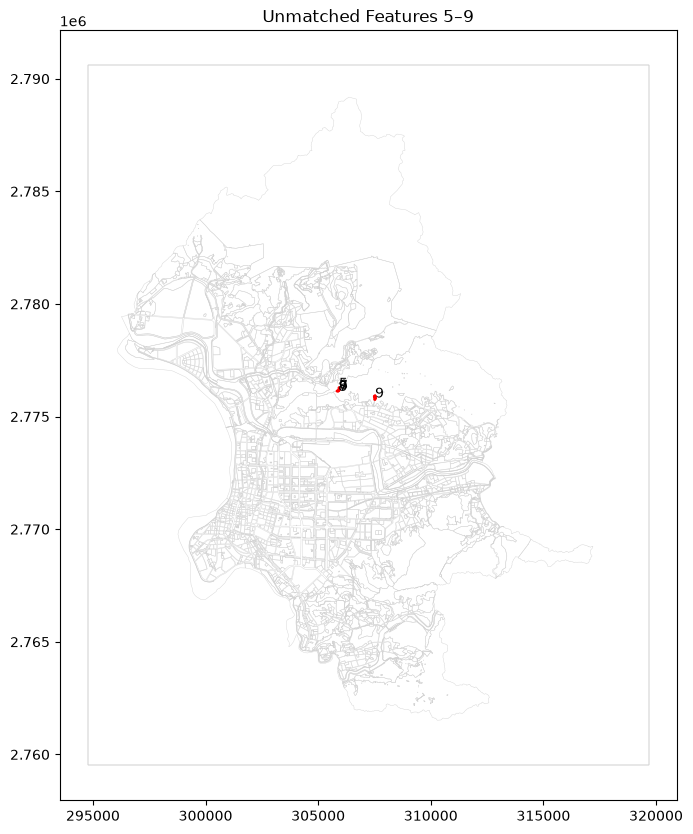

In [36]:
#把5-9直接畫在整份土地使用圖上
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

# 整份土地使用資料作為底圖
geometry_cleaned.plot(
    ax=ax,
    facecolor="none",
    edgecolor="lightgray",
    linewidth=0.3
)

# 5–9 疑似異常 geometry
blank_features.plot(
    ax=ax,
    edgecolor="red",
    facecolor="yellow",
    linewidth=2
)

# 在 geometry 中心附近標示編號
for idx, row in blank_features.iterrows():
    point = row.geometry.representative_point()

    ax.text(
        point.x,
        point.y,
        row["編號"],
        fontsize=10
    )

ax.set_title("Unmatched Features 5–9")
plt.show()

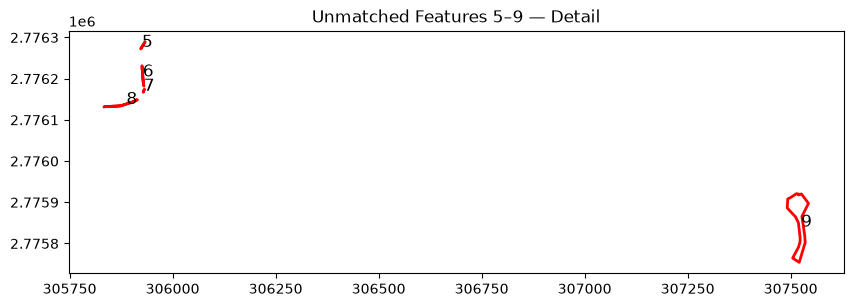

In [37]:
#放大成局部圖觀看5-9的位置
fig, ax = plt.subplots(figsize=(10, 10))

blank_features.plot(
    ax=ax,
    edgecolor="red",
    facecolor="none",
    linewidth=2
)

for idx, row in blank_features.iterrows():
    point = row.geometry.representative_point()

    ax.text(
        point.x,
        point.y,
        row["編號"],
        fontsize=12
    )

ax.set_title("Unmatched Features 5–9 — Detail")
plt.show()

In [38]:
#檢查是否與其他土地使用分區的polygon重疊
# ==========================================
# Task 05-B2 Step 04
# Spatial Join：檢查 5–9 與哪些土地使用區相交
# ==========================================

# 1. 正式土地使用 features
valid_landuse_features = landuse_processed.loc[
    landuse_processed["main_category"].notna()
].copy()


# 2. 只取需要的欄位，並先重新命名
landuse_for_join = (
    valid_landuse_features[
        ["編號", "使用分區", "main_category", "geometry"]
    ]
    .rename(
        columns={
            "編號": "matched_id",
            "使用分區": "matched_zone",
            "main_category": "matched_category"
        }
    )
)


# 3. 執行 Spatial Join
overlap_check = blank_features.sjoin(
    landuse_for_join,
    how="left",
    predicate="intersects"
)


# 4. 顯示結果
print("=== 5–9 與土地使用 Feature 的相交結果 ===")

print(
    overlap_check[
        [
            "編號",
            "area_m2",
            "matched_id",
            "matched_zone",
            "matched_category"
        ]
    ].to_string(index=False)
)

=== 5–9 與土地使用 Feature 的相交結果 ===
編號     area_m2 matched_id matched_zone matched_category
 5    2.124929        227          保護區             保護保育
 5    2.124929       2099          保護區             保護保育
 6    3.264799        227          保護區             保護保育
 6    3.264799       2099          保護區             保護保育
 7    0.433609        227          保護區             保護保育
 7    0.433609       2099          保護區             保護保育
 8    9.979318        227          保護區             保護保育
 8    9.979318       2099          保護區             保護保育
 9 3429.009460       2099          保護區             保護保育
 9 3429.009460       3739       電力設施用地           公共事業設施
 9 3429.009460       3738       電力設施用地           公共事業設施


Task 05 B3 計算實際重疊面積
使用intersection()

In [39]:
# ==========================================
# Task 05-B3
# 計算 unmatched feature 與土地使用區的實際重疊面積
# ==========================================

# 先建立一份結果副本
overlap_area_check = overlap_check.copy()


# 取得 matched feature 的 geometry
matched_geometry = (
    landuse_for_join
    .geometry
    .reindex(overlap_area_check["index_right"])
    .reset_index(drop=True)
)

# unmatched feature 自己的 geometry
blank_geometry = (
    overlap_area_check.geometry
    .reset_index(drop=True)
)


# 計算兩個 geometry 的 intersection
intersections = [
    geom_blank.intersection(geom_matched)
    for geom_blank, geom_matched
    in zip(blank_geometry, matched_geometry)
]


# 計算實際重疊面積
overlap_area_check["overlap_area_m2"] = [
    geom.area for geom in intersections
]


# 計算重疊比例
overlap_area_check["overlap_pct"] = (
    overlap_area_check["overlap_area_m2"]
    / overlap_area_check["area_m2"]
    * 100
)


print(
    overlap_area_check[
        [
            "編號",
            "area_m2",
            "matched_id",
            "matched_zone",
            "matched_category",
            "overlap_area_m2",
            "overlap_pct"
        ]
    ].to_string(index=False)
)

編號     area_m2 matched_id matched_zone matched_category  overlap_area_m2  overlap_pct
 5    2.124929        227          保護區             保護保育         2.124929   100.000000
 5    2.124929       2099          保護區             保護保育         0.000000     0.000000
 6    3.264799        227          保護區             保護保育         3.264799   100.000000
 6    3.264799       2099          保護區             保護保育         0.000000     0.000000
 7    0.433609        227          保護區             保護保育         0.433609   100.000000
 7    0.433609       2099          保護區             保護保育         0.000000     0.000000
 8    9.979318        227          保護區             保護保育         9.979064    99.997456
 8    9.979318       2099          保護區             保護保育         0.000000     0.000000
 9 3429.009460       2099          保護區             保護保育         0.000000     0.000000
 9 3429.009460       3739       電力設施用地           公共事業設施         0.000000     0.000000
 9 3429.009460       3738       電力設施用地           公共事業設

task 05-A~C結論：
不用理會編號1-9的資料，1-4是計畫範圍，5-9的區域已包含在其他土地使用分區中，且面積過小，不須納入計算

Task 05-C 建立正式分析用的Landuse Dataset
把資料拆成
landuse_processed
|
|－landuse_analytical -> 3832筆，後續GIS分析使用
|
|－excluded_features -> 8筆，保留QA/traceability

In [40]:
#建立excluded layer
# ==========================================
# Task 05-C
# 建立正式 Analytical Land-use Dataset
# ==========================================

# 1. 取出不納入土地使用分析的 8 筆 feature
excluded_features = (
    landuse_processed.loc[
        landuse_processed["main_category"].isna()
    ]
    .copy()
)

excluded_features["qa_status"] = ""

# 編號 1–3：規劃範圍
excluded_features.loc[
    excluded_features["編號"].isin(["1", "2", "3"]),
    "qa_status"
] = "excluded_planning_extent"


# 編號 5–8：完全/近乎完全被保護區覆蓋的無屬性 geometry
excluded_features.loc[
    excluded_features["編號"].isin(["5", "6", "7", "8"]),
    "qa_status"
] = "excluded_unattributed_overlap_protected"


# 編號 9：完全被電力設施用地覆蓋
excluded_features.loc[
    excluded_features["編號"] == "9",
    "qa_status"
] = "excluded_unattributed_overlap_utility"

In [41]:
#建立正式analytical layer
landuse_analytical = (
    landuse_processed.loc[
        landuse_processed["main_category"].notna()
    ]
    .copy()
)


In [42]:
#正式計算面積

landuse_analytical["area_m2"] = (
    landuse_analytical.geometry.area
)

landuse_analytical["area_km2"] = (
    landuse_analytical["area_m2"] / 1_000_000
)

In [43]:
#輸出成果
print("=== Analytical Land-use Dataset QA ===")

print("原 processed features：", len(landuse_processed))
print("排除 features：", len(excluded_features))
print("正式分析 features：", len(landuse_analytical))

print(
    "Invalid geometry：",
    (~landuse_analytical.geometry.is_valid).sum()
)

print(
    "Empty geometry：",
    landuse_analytical.geometry.is_empty.sum()
)

print(
    "Missing main_category：",
    landuse_analytical["main_category"].isna().sum()
)

print(
    "CRS：",
    landuse_analytical.crs
)

=== Analytical Land-use Dataset QA ===
原 processed features： 3840
排除 features： 8
正式分析 features： 3832
Invalid geometry： 0
Empty geometry： 0
Missing main_category： 0
CRS： EPSG:3826


In [44]:
#製作第一張正式成果統計表
category_area_summary = (
    landuse_analytical
    .groupby("main_category")
    .agg(
        feature_count=("編號", "count"),
        area_m2=("area_m2", "sum"),
        area_km2=("area_km2", "sum")
    )
    .sort_values(
        "area_km2",
        ascending=False
    )
    .reset_index()
)

#計算各類面積占比
total_area_km2 = category_area_summary["area_km2"].sum()

category_area_summary["area_pct"] = (
    category_area_summary["area_km2"]
    / total_area_km2
    * 100
)

print("\n=== Main Category 面積統計 ===")

print(
    category_area_summary.to_string(
        index=False,
        formatters={
            "area_m2": "{:,.2f}".format,
            "area_km2": "{:,.3f}".format,
            "area_pct": "{:.2f}%".format
        }
    )
)




=== Main Category 面積統計 ===
main_category  feature_count        area_m2 area_km2 area_pct
         保護保育            211 119,959,311.88  119.959   47.15%
           住宅            730  45,961,725.37   45.962   18.07%
         水域水利            261  18,309,124.38   18.309    7.20%
       公園綠地遊憩            433  13,847,293.74   13.847    5.44%
           文教            383  11,406,297.14   11.406    4.48%
         商業服務            625  10,065,939.31   10.066    3.96%
         交通運輸            400   7,695,030.34    7.695    3.02%
       公共行政服務            279   7,259,797.32    7.260    2.85%
           農業             36   5,506,885.16    5.507    2.16%
         工業產業             95   4,754,769.31    4.755    1.87%
         特殊專用             98   4,571,338.95    4.571    1.80%
       公共事業設施            198   2,619,196.23    2.619    1.03%
           殯葬             23   1,811,540.05    1.812    0.71%
       文化宗教保存             60     625,907.61    0.626    0.25%


Task 06 Polygon Topology/Overlap QA
利用geopandas的spatial index
Task 06-A 快速找出有空間相交的候選組合

In [45]:
# ==========================================
# Task 06
# Polygon Topology / Overlap QA
# ==========================================


# 1. 建立左右兩份資料
left_features = (
    landuse_analytical[
        ["編號", "使用分區", "main_category", "geometry"]
    ]
    .rename(
        columns={
            "編號": "id_left",
            "使用分區": "zone_left",
            "main_category": "category_left"
        }
    )
)

right_features = (
    landuse_analytical[
        ["編號", "使用分區", "main_category", "geometry"]
    ]
    .rename(
        columns={
            "編號": "id_right",
            "使用分區": "zone_right",
            "main_category": "category_right"
        }
    )
)


# 2. 找所有 spatial intersects
overlap_candidates = left_features.sjoin(
    right_features,
    how="inner",
    predicate="intersects"
)


# 3. 移除自己和自己
overlap_candidates = overlap_candidates.loc[
    overlap_candidates["id_left"]
    != overlap_candidates["id_right"]
].copy()


# 4. 移除 A-B / B-A 重複組合
overlap_candidates = overlap_candidates.loc[
    overlap_candidates["id_left"].astype(int)
    <
    overlap_candidates["id_right"].astype(int)
].copy()


print("=== Polygon Intersect Candidate QA ===")
print("候選 polygon pairs：", len(overlap_candidates))


# 5. 建立 geometry lookup
geometry_lookup = (
    landuse_analytical
    .set_index("編號")
    .geometry
)


# 6. 計算真正 intersection area
overlap_candidates["overlap_area_m2"] = (
    overlap_candidates.apply(
        lambda row:
        row.geometry.intersection(
            geometry_lookup[row["id_right"]]
        ).area,
        axis=1
    )
)


# 7. 排除只有邊界接觸 / 極小浮點誤差
real_overlaps = overlap_candidates.loc[
    overlap_candidates["overlap_area_m2"] > 0.01
].copy()


# 8. 依 overlap 面積排序
real_overlaps = (
    real_overlaps
    .sort_values(
        "overlap_area_m2",
        ascending=False
    )
)


print("\n=== Real Polygon Overlaps ===")
print("實際 overlap pairs：", len(real_overlaps))

print(
    real_overlaps[
        [
            "id_left",
            "zone_left",
            "category_left",
            "id_right",
            "zone_right",
            "category_right",
            "overlap_area_m2"
        ]
    ].head(30).to_string(index=False)
)

=== Polygon Intersect Candidate QA ===
候選 polygon pairs： 4607

=== Real Polygon Overlaps ===
實際 overlap pairs： 1016
id_left zone_left category_left id_right zone_right category_right  overlap_area_m2
     19       河川區          水域水利     1820        行水區           水域水利    196501.625521
    560       保護區          保護保育     1611        保護區           保護保育      8232.221018
    386       河川區          水域水利      510        河川區           水域水利      3991.677835
   1913       保護區          保護保育     3598       機關用地         公共行政服務      1640.217795
   2413     排水溝用地          水域水利     3064      排水溝用地           水域水利      1573.747373
   2414     排水溝用地          水域水利     3064      排水溝用地           水域水利      1218.374499
   2333      綠地用地        公園綠地遊憩     2356       綠地用地         公園綠地遊憩      1080.539701
   2412     排水溝用地          水域水利     3064      排水溝用地           水域水利       888.156551
   2414     排水溝用地          水域水利     3097      排水溝用地           水域水利       820.443092
   1526       商業區          商業服務     3417    

Task 06-C 同類內部overlap vs 跨類別overlap

In [46]:
# ==========================================
# Task 06-C
# Same-category vs Cross-category Overlap
# ==========================================
#建立overlap類型
real_overlaps["overlap_type"] = (
    real_overlaps.apply(
        lambda row:
        "same_category"
        if row["category_left"] == row["category_right"]
        else "cross_category",
        axis=1
    )
)

#統計pair數量與overlap面積
overlap_type_summary = (
    real_overlaps
    .groupby("overlap_type")
    .agg(
        pair_count=("overlap_area_m2", "count"),
        total_overlap_m2=("overlap_area_m2", "sum"),
        max_overlap_m2=("overlap_area_m2", "max")
    )
)

overlap_type_summary["total_overlap_km2"] = (
    overlap_type_summary["total_overlap_m2"]
    / 1_000_000
)

print("=== Overlap Type Summary ===")
print(overlap_type_summary)

=== Overlap Type Summary ===
                pair_count  total_overlap_m2  max_overlap_m2  \
overlap_type                                                   
cross_category         857       3106.872306     1640.217795   
same_category          159     215070.615320   196501.625521   

                total_overlap_km2  
overlap_type                       
cross_category           0.003107  
same_category            0.215071  


In [47]:
#只抓真正重要的cross-category overlap
cross_category_overlaps = (
    real_overlaps.loc[
        real_overlaps["overlap_type"] == "cross_category"
    ]
    .copy()
    .sort_values(
        "overlap_area_m2",
        ascending=False
    )
)

print(
    "\nCross-category overlap pairs:",
    len(cross_category_overlaps)
)

print("\n=== 最大的 Cross-category Overlaps ===")

print(
    cross_category_overlaps[
        [
            "id_left",
            "zone_left",
            "category_left",
            "id_right",
            "zone_right",
            "category_right",
            "overlap_area_m2"
        ]
    ]
    .head(30)
    .to_string(index=False)
)


Cross-category overlap pairs: 857

=== 最大的 Cross-category Overlaps ===
id_left zone_left category_left id_right zone_right category_right  overlap_area_m2
   1913       保護區          保護保育     3598       機關用地         公共行政服務      1640.217795
   1526       商業區          商業服務     3417       交通用地           交通運輸       277.133991
    842       住宅區            住宅     2715       交通用地           交通運輸       182.953144
   2157      公園用地        公園綠地遊憩     3606       堤防用地           水域水利        36.467823
   2717      堤防用地          水域水利     2784       公園用地         公園綠地遊憩        18.050078
   2080       保護區          保護保育     2738       河道用地           水域水利        17.874496
    560       保護區          保護保育     3104      排水溝用地           水域水利        15.277231
   2717      堤防用地          水域水利     2785       公園用地         公園綠地遊憩        13.541441
   1972       河川區          水域水利     2007        住宅區             住宅        11.920904
   1147       農業區            農業     1953        河川區           水域水利        11.064923
    

In [48]:
#依｢類別組合」統計
cross_category_overlaps["category_pair"] = (
    cross_category_overlaps.apply(
        lambda row:
        " × ".join(
            sorted([
                row["category_left"],
                row["category_right"]
            ])
        ),
        axis=1
    )
)

cross_category_summary = (
    cross_category_overlaps
    .groupby("category_pair")
    .agg(
        pair_count=("overlap_area_m2", "count"),
        total_overlap_m2=("overlap_area_m2", "sum"),
        max_overlap_m2=("overlap_area_m2", "max")
    )
    .sort_values(
        "total_overlap_m2",
        ascending=False
    )
)

cross_category_summary["total_overlap_km2"] = (
    cross_category_summary["total_overlap_m2"]
    / 1_000_000
)

print("\n=== Cross-category Overlap Summary ===")
print(cross_category_summary.head(20))


=== Cross-category Overlap Summary ===
               pair_count  total_overlap_m2  max_overlap_m2  total_overlap_km2
category_pair                                                                 
保護保育 × 公共行政服務           5       1643.606179     1640.217795           0.001644
交通運輸 × 商業服務            31        299.414092      277.133991           0.000299
交通運輸 × 住宅              54        250.665822      182.953144           0.000251
公園綠地遊憩 × 水域水利          42        140.313067       36.467823           0.000140
住宅 × 水域水利              46         95.441910       11.920904           0.000095
住宅 × 公園綠地遊憩           106         92.464009        8.462755           0.000092
住宅 × 保護保育              59         72.478815        6.988213           0.000072
住宅 × 文教                96         59.785109        3.922541           0.000060
保護保育 × 水域水利            15         57.736120       17.874496           0.000058
住宅 × 商業服務             100         51.425668        3.847081           0.000051
交通運輸 × 水域水利 

Task 07 Dissolve by main_category

In [49]:
# ==========================================
# Task 07-A
# Dissolve by main_category
# ==========================================

landuse_dissolved = (
    landuse_analytical
    .dissolve(
        by="main_category"
    )
    .reset_index()
)

print("Dissolved features:", len(landuse_dissolved))

print(
    landuse_dissolved[
        ["main_category", "geometry"]
    ].head()
)

Dissolved features: 14
  main_category                                           geometry
0          交通運輸  MULTIPOLYGON (((300315.871 2768292.21, 300321....
1            住宅  MULTIPOLYGON (((300445.291 2768211.808, 300451...
2          保護保育  MULTIPOLYGON (((304532.798 2766893.819, 304527...
3        公共事業設施  MULTIPOLYGON (((303898.843 2767256.685, 303878...
4        公共行政服務  MULTIPOLYGON (((300259.201 2768390.399, 300259...


In [50]:
#重新檢查gemoetry type
print("\n=== Dissolved Geometry Type ===")

print(
    landuse_dissolved.geometry
    .geom_type
    .value_counts()
)


=== Dissolved Geometry Type ===
MultiPolygon    14
Name: count, dtype: int64


In [51]:
#Dissolve後重新計算面積
landuse_dissolved["area_m2"] = (
    landuse_dissolved.geometry.area
)

landuse_dissolved["area_km2"] = (
    landuse_dissolved["area_m2"] / 1_000_000
)

#與原本加總面積比較
dissolved_area_summary = (
    landuse_dissolved[
        ["main_category", "area_km2"]
    ]
    .rename(
        columns={
            "area_km2": "dissolved_area_km2"
        }
    )
)

area_comparison = (
    category_area_summary[
        ["main_category", "area_km2"]
    ]
    .merge(
        dissolved_area_summary,
        on="main_category",
        how="left"
    )
)

In [52]:
#算｢因overlap被重複計算多少」
area_comparison["overlap_removed_km2"] = (
    area_comparison["area_km2"]
    - area_comparison["dissolved_area_km2"]
)

area_comparison["overlap_removed_pct"] = (
    area_comparison["overlap_removed_km2"]
    / area_comparison["area_km2"]
    * 100
)

In [53]:
#輸出結果
area_comparison = (
    area_comparison
    .sort_values(
        "overlap_removed_km2",
        ascending=False
    )
)

print("=== Area Before vs After Dissolve ===")

print(
    area_comparison.to_string(
        index=False,
        formatters={
            "area_km2": "{:.3f}".format,
            "dissolved_area_km2": "{:.3f}".format,
            "overlap_removed_km2": "{:.6f}".format,
            "overlap_removed_pct": "{:.4f}%".format
        }
    )
)

=== Area Before vs After Dissolve ===
main_category area_km2 dissolved_area_km2 overlap_removed_km2 overlap_removed_pct
         水域水利   18.309             18.104            0.205450             1.1221%
         保護保育  119.959            119.951            0.008403             0.0070%
       公園綠地遊憩   13.847             13.846            0.001108             0.0080%
         交通運輸    7.695              7.695            0.000091             0.0012%
           住宅   45.962             45.962            0.000007             0.0000%
         工業產業    4.755              4.755            0.000004             0.0001%
         商業服務   10.066             10.066            0.000003             0.0000%
           文教   11.406             11.406            0.000003             0.0000%
       公共行政服務    7.260              7.260            0.000001             0.0000%
           農業    5.507              5.507            0.000001             0.0000%
         特殊專用    4.571              4.571            0.00000

目前結論：原始土地使用 polygon 存在同類別空間重疊。經 topology QA 後，以 main_category 進行 Dissolve，消除同類別內部的重複計算。水域水利類別受影響最明顯，面積由約 18.309 km² 修正為 18.104 km²，減少約 1.12%；其餘類別差異極小。

In [54]:
# ==========================================
# Task 07-B
# 建立正式 Main Category 面積成果表
# ==========================================

final_area_summary = (
    landuse_dissolved[
        ["main_category", "area_m2", "area_km2"]
    ]
    .copy()
)

# 計算 dissolve 後總面積
total_dissolved_area_km2 = (
    final_area_summary["area_km2"].sum()
)

# 計算各類別占本資料集的比例
final_area_summary["area_pct"] = (
    final_area_summary["area_km2"]
    / total_dissolved_area_km2
    * 100
)

# 依面積由大到小排序
final_area_summary = (
    final_area_summary
    .sort_values(
        "area_km2",
        ascending=False
    )
    .reset_index(drop=True)
)

print("=== Final Main Category Area Summary ===")

print(
    final_area_summary.to_string(
        index=False,
        formatters={
            "area_m2": "{:,.2f}".format,
            "area_km2": "{:.3f}".format,
            "area_pct": "{:.2f}%".format
        }
    )
)

print(
    f"\nDissolved dataset total area: "
    f"{total_dissolved_area_km2:.3f} km²"
)

=== Final Main Category Area Summary ===
main_category        area_m2 area_km2 area_pct
         保護保育 119,950,908.87  119.951   47.19%
           住宅  45,961,718.64   45.962   18.08%
         水域水利  18,103,674.15   18.104    7.12%
       公園綠地遊憩  13,846,186.08   13.846    5.45%
           文教  11,406,294.30   11.406    4.49%
         商業服務  10,065,936.39   10.066    3.96%
         交通運輸   7,694,939.64    7.695    3.03%
       公共行政服務   7,259,796.18    7.260    2.86%
           農業   5,506,884.24    5.507    2.17%
         工業產業   4,754,765.15    4.755    1.87%
         特殊專用   4,571,338.65    4.571    1.80%
       公共事業設施   2,619,196.23    2.619    1.03%
           殯葬   1,811,540.05    1.812    0.71%
       文化宗教保存     625,907.61    0.626    0.25%

Dissolved dataset total area: 254.179 km²


Task 08-A 建立14類土地使用成果圖

In [55]:
#建立固定色彩mapping
category_colors = {
    "住宅": "#F4A6A6",
    "商業服務": "#D95F5F",
    "工業產業": "#B07AA1",
    "文教": "#F2D06B",
    "公共行政服務": "#E69F66",
    "公共事業設施": "#8C8C8C",
    "交通運輸": "#595959",
    "公園綠地遊憩": "#7FBF7B",
    "水域水利": "#5DADE2",
    "農業": "#B8D986",
    "保護保育": "#4F8A5B",
    "文化宗教保存": "#C49A6C",
    "殯葬": "#756BB1",
    "特殊專用": "#D9D9D9"
}

#建立每筆feature的顏色
#.map會依照dictionary找到值，碰到住宅→會找到"#F4A6A6""
landuse_analytical["plot_color"] = (
    landuse_analytical["main_category"]
    .map(category_colors)
)

#檢查有沒有漏掉的category
missing_colors = (
    landuse_analytical.loc[
        landuse_analytical["plot_color"].isna(),
        "main_category"
    ]
    .unique()
)

print("Missing color categories:", missing_colors)

Missing color categories: <StringArray>
[]
Length: 0, dtype: str


C:\Users\RollyHe\AppData\Local\Temp\ipykernel_17444\4187350929.py:46: UserWarning: Glyph 33274 (\N{CJK UNIFIED IDEOGRAPH-81FA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\RollyHe\AppData\Local\Temp\ipykernel_17444\4187350929.py:46: UserWarning: Glyph 21271 (\N{CJK UNIFIED IDEOGRAPH-5317}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\RollyHe\AppData\Local\Temp\ipykernel_17444\4187350929.py:46: UserWarning: Glyph 24066 (\N{CJK UNIFIED IDEOGRAPH-5E02}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\RollyHe\AppData\Local\Temp\ipykernel_17444\4187350929.py:46: UserWarning: Glyph 22303 (\N{CJK UNIFIED IDEOGRAPH-571F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\RollyHe\AppData\Local\Temp\ipykernel_17444\4187350929.py:46: UserWarning: Glyph 22320 (\N{CJK UNIFIED IDEOGRAPH-5730}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\RollyHe\AppData\Local\Temp\ipykernel_17444\4187350929.py:46: UserWarning: Gl

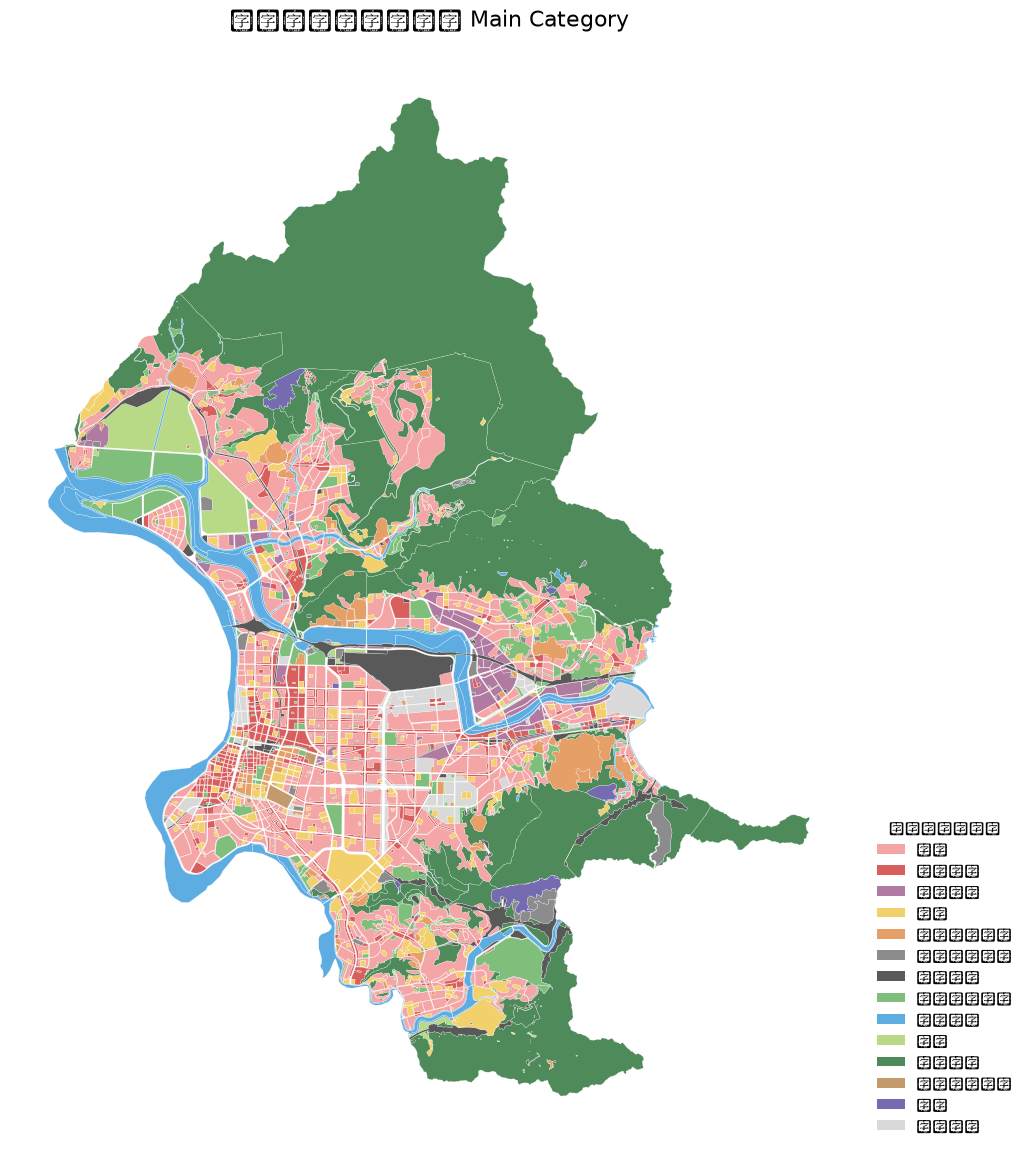

In [56]:
#產出土地使用圖
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ==========================================
# Task 08-A
# Main Category Land-use Map
# ==========================================

fig, ax = plt.subplots(figsize=(10, 12))

# 畫土地使用 polygon
landuse_analytical.plot(
    ax=ax,
    color=landuse_analytical["plot_color"],
    edgecolor="white",
    linewidth=0.15
)

# 建立 legend
legend_handles = [
    Patch(
        facecolor=color,
        edgecolor="none",
        label=category
    )
    for category, color in category_colors.items()
]

ax.legend(
    handles=legend_handles,
    title="土地使用主分類",
    loc="lower left",
    bbox_to_anchor=(1.02, 0),
    frameon=False
)

ax.set_title(
    "臺北市土地使用分區 Main Category",
    fontsize=16,
    pad=15
)

ax.set_axis_off()

plt.tight_layout()

plt.show()

Task 08-A2 修正Matplotlib中文字型

In [57]:
import matplotlib.font_manager as fm

font_names = sorted(
    set(font.name for font in fm.fontManager.ttflist)
)

for font in font_names:
    if "Jheng" in font or "Hei" in font or "Noto" in font:
        print(font)

DFHeiBold-B5
DFHeiLight-B5
DFHeiMedium-B5
DFHeiUBold-B5
DFLiHei-Bd
DFLiHei-Lt
DFLiHei-Md
DFLiKingHei-XB
DFNHeiXBold-B5
DFPHeiBold-B5
DFPHeiLight-B5
DFPHeiMedium-B5
DFPHeiUBold-B5
DFPLiHei-Bd
DFPLiHei-Lt
DFPLiHei-Md
DFPLiKingHei-XB
DFPNHeiXBold-B5
Microsoft JhengHei
Microsoft JhengHei Light
Microsoft JhengHei UI
Microsoft JhengHei UI Light
Microsoft YaHei
Microsoft YaHei Light
Microsoft YaHei UI
Microsoft YaHei UI Light
Noto Sans HK
Noto Sans JP
Noto Sans KR
Noto Sans TC
Noto Sans TC Thin
Noto Serif HK
Noto Serif JP
Noto Serif KR
Noto Serif TC


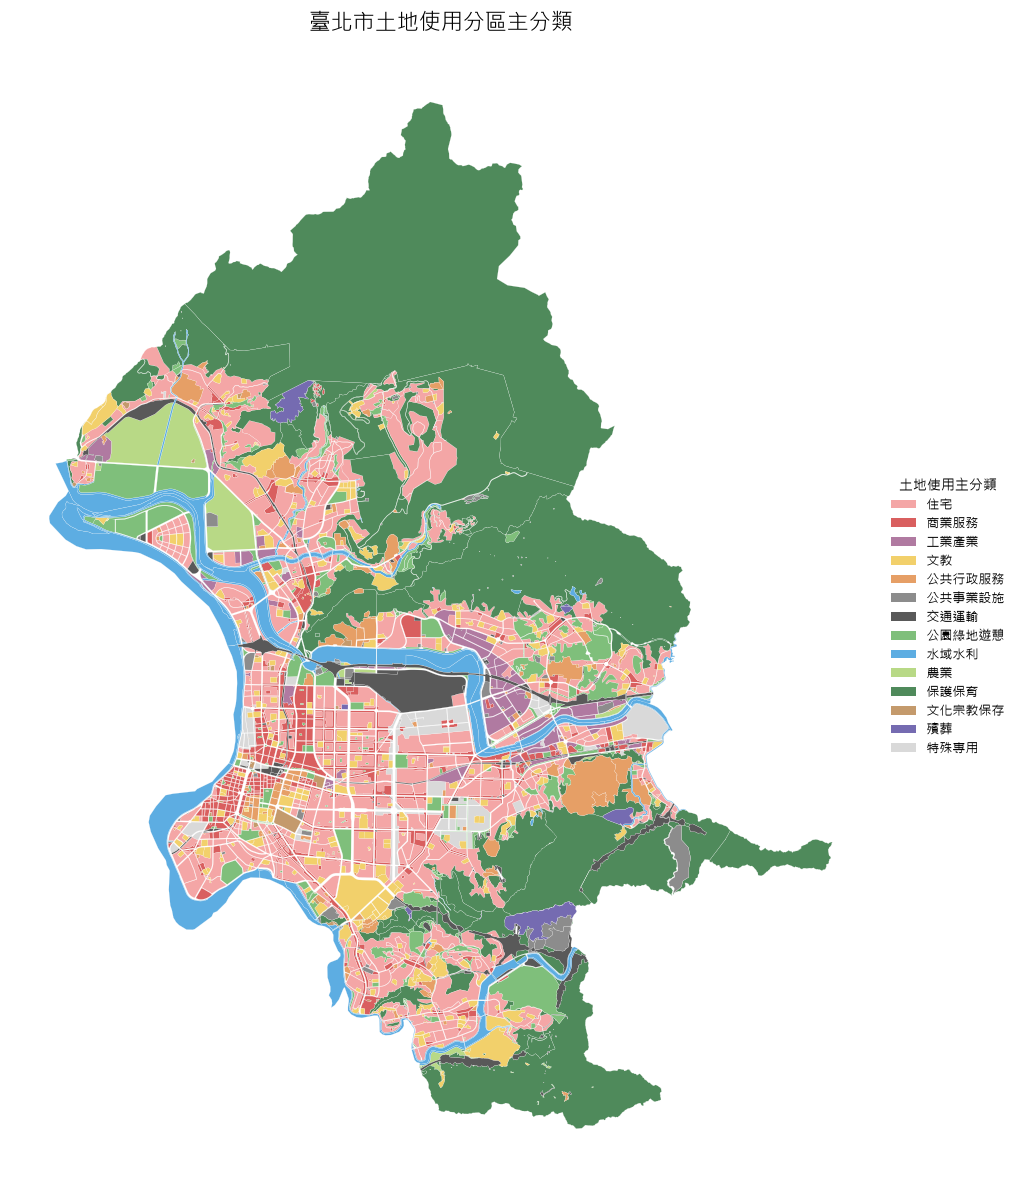

In [58]:
#重新畫圖

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ==========================================
# Task 08-A2
# Main Category Land-use Map
# 修正版：中文字體 + 圖例版面
# ==========================================

# 中文字體
plt.rcParams["font.family"] = "Microsoft JhengHei"
plt.rcParams["axes.unicode_minus"] = False


# 建立畫布
fig, ax = plt.subplots(figsize=(10, 12))


# 畫土地使用 polygon
landuse_analytical.plot(
    ax=ax,
    color=landuse_analytical["plot_color"],
    edgecolor="white",
    linewidth=0.12
)


# 建立自訂圖例
legend_handles = [
    Patch(
        facecolor=color,
        edgecolor="none",
        label=category
    )
    for category, color in category_colors.items()
]


# 圖例
ax.legend(
    handles=legend_handles,
    title="土地使用主分類",
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    frameon=False,
    fontsize=9,
    title_fontsize=10
)


# 標題
ax.set_title(
    "臺北市土地使用分區主分類",
    fontsize=16,
    pad=15
)


# 移除座標軸
ax.set_axis_off()


# 自動調整版面
plt.tight_layout()

plt.show()

Task 08-A3 台北市都市計畫圖例風格色彩

In [59]:
# ==========================================
# Task 08-A3
# 臺北市都市計畫圖例風格 Main Category 色彩
# ==========================================

category_colors = {

    # 法定住宅區：RGB(255,255,0)
    "住宅": "#FFFF00",

    # 法定商業區：RGB(255,0,63)
    "商業服務": "#FF003F",

    # 法定工業區：RGB(127,63,0)
    "工業產業": "#7F3F00",

    # 法定文教區：RGB(191,127,255)
    "文教": "#BF7FFF",

    # 行政 / 機關類：RGB(0,127,255)
    "公共行政服務": "#007FFF",

    # 公共事業設施多為灰色系：RGB(183,183,183)
    "公共事業設施": "#B7B7B7",

    # 交通種類本身有多種官方顏色
    # main_category 整合圖先以深灰表示交通骨架
    "交通運輸": "#666666",

    # 公園綠地：RGB(0,255,0)
    "公園綠地遊憩": "#00FF00",

    # 河川 / 水岸發展：RGB(127,255,255)
    "水域水利": "#7FFFFF",

    # 農業區：RGB(127,255,0)
    "農業": "#7FFF00",

    # 保護區官方也是 RGB(127,255,0)
    # 但為避免和農業完全無法區辨，
    # 14大類分析圖改用較深綠色
    "保護保育": "#008000",

    # 保存 / 宗教類在官方圖例中並非單一色彩
    # 以綠色系較深色代表
    "文化宗教保存": "#4CAF50",

    # 公墓 / 殯葬在官方圖例中也非單一純色
    # 以較深紫灰區隔
    "殯葬": "#8064A2",

    # 沒有單一法定色彩可代表
    "特殊專用": "#D9D9D9"
}

In [60]:
landuse_analytical["plot_color"] = (
    landuse_analytical["main_category"]
    .map(category_colors)
)

In [61]:
missing_colors = (
    landuse_analytical.loc[
        landuse_analytical["plot_color"].isna(),
        "main_category"
    ]
    .unique()
)

print("Missing color categories:", missing_colors)

Missing color categories: <StringArray>
[]
Length: 0, dtype: str


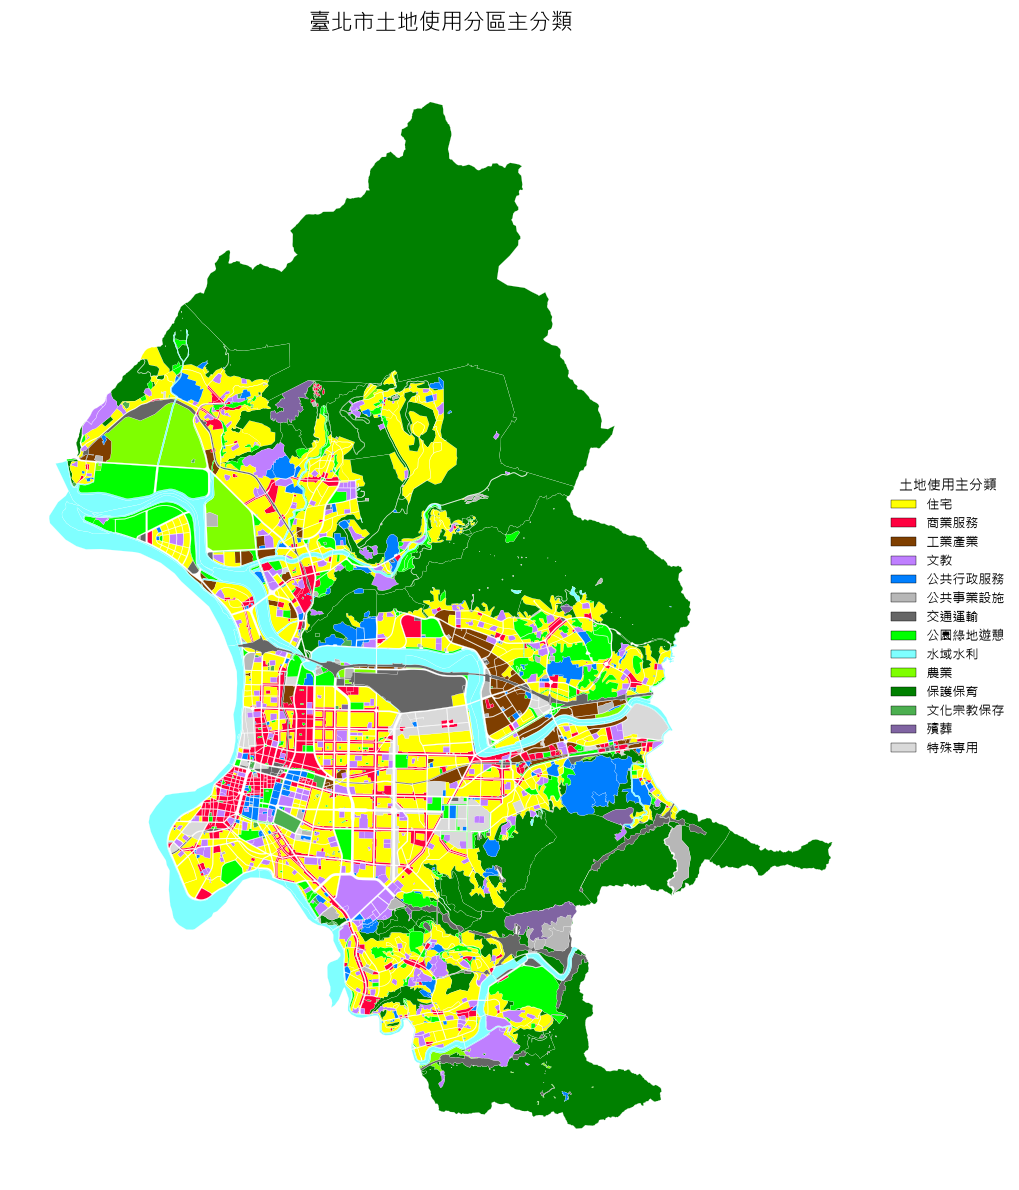

In [62]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

plt.rcParams["font.family"] = "Microsoft JhengHei"
plt.rcParams["axes.unicode_minus"] = False


fig, ax = plt.subplots(figsize=(10, 12))


# 土地使用圖
landuse_analytical.plot(
    ax=ax,
    color=landuse_analytical["plot_color"],
    edgecolor="white",
    linewidth=0.12
)


# 圖例
legend_handles = [
    Patch(
        facecolor=color,
        edgecolor="black",
        linewidth=0.3,
        label=category
    )
    for category, color in category_colors.items()
]


ax.legend(
    handles=legend_handles,
    title="土地使用主分類",
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    frameon=False,
    fontsize=9,
    title_fontsize=10
)


ax.set_title(
    "臺北市土地使用分區主分類",
    fontsize=16,
    pad=15
)

ax.set_axis_off()

plt.tight_layout()

plt.show()

Task 08-A4 建立正式輸出版本

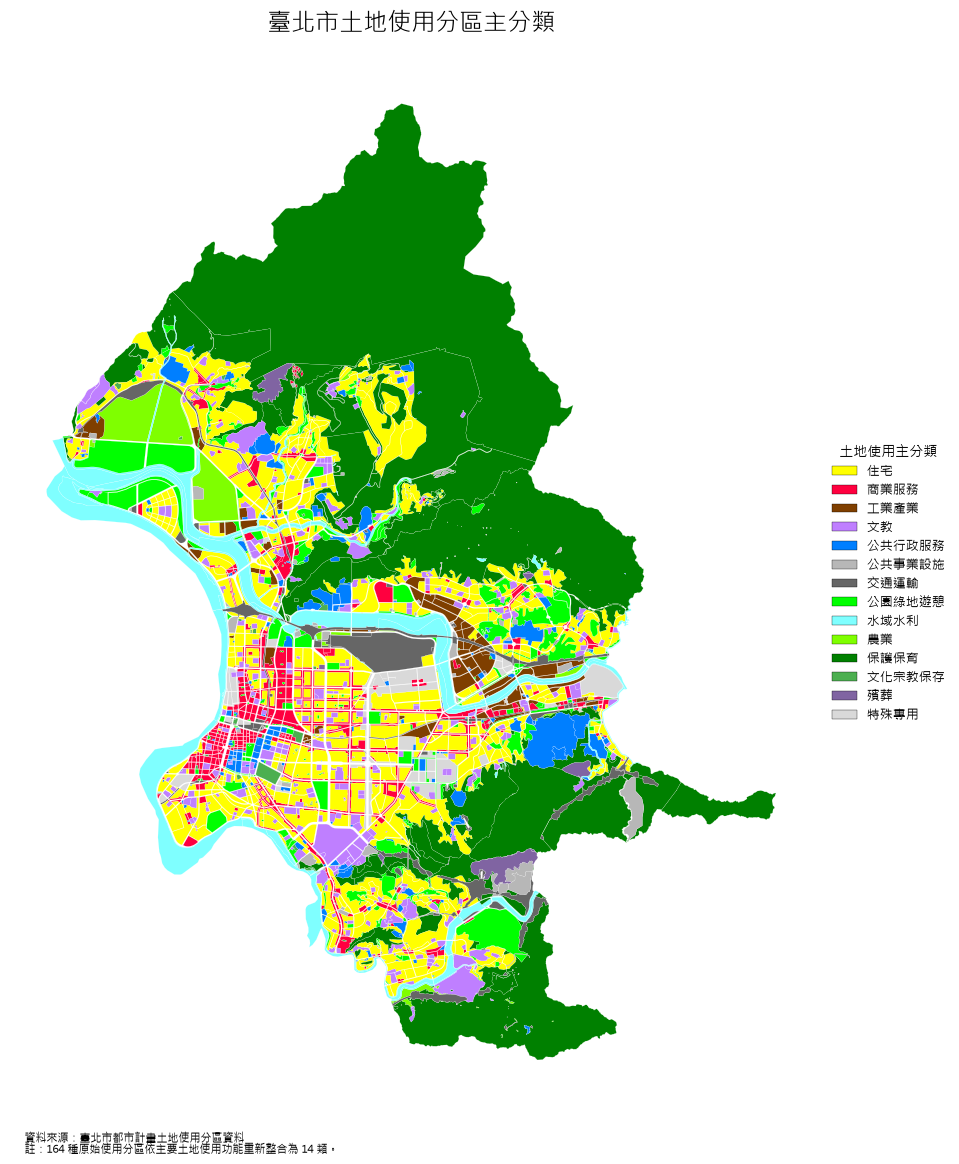

In [63]:
fig_map, ax = plt.subplots(figsize=(11, 12))

landuse_analytical.plot(
    ax=ax,
    color=landuse_analytical["plot_color"],
    edgecolor="white",
    linewidth=0.10
)

legend_handles = [
    Patch(
        facecolor=color,
        edgecolor="black",
        linewidth=0.25,
        label=category
    )
    for category, color in category_colors.items()
]

ax.legend(
    handles=legend_handles,
    title="土地使用主分類",
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    frameon=False,
    fontsize=9,
    title_fontsize=10
)

ax.set_title(
    "臺北市土地使用分區主分類",
    fontsize=17,
    pad=18
)

# 地圖下方註解
fig_map.text(
    0.12,
    0.035,
    "資料來源：臺北市都市計畫土地使用分區資料\n"
    "註：164 種原始使用分區依主要土地使用功能重新整合為 14 類。",
    fontsize=8,
    ha="left"
)

ax.set_axis_off()

plt.tight_layout(rect=[0, 0.06, 1, 1])

plt.show()

Task 08-B Main Category面積排名圖

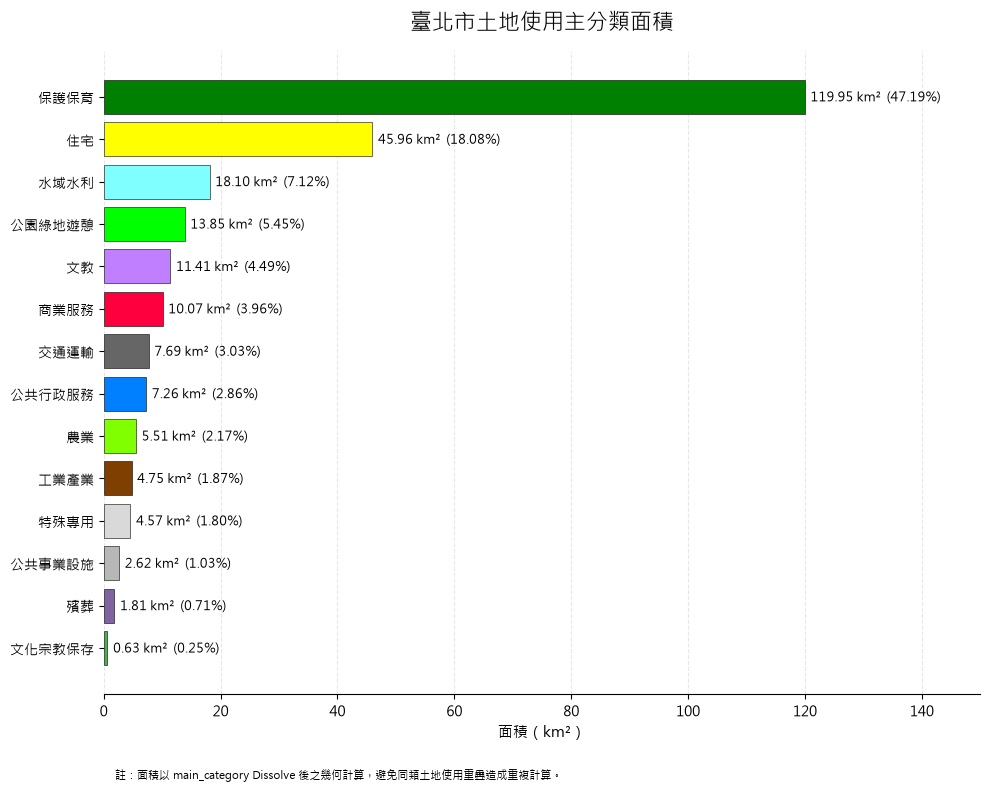

In [64]:
# ==========================================
# Task 08-B
# Main Category Area Ranking Bar Chart
# ==========================================

import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Microsoft JhengHei"
plt.rcParams["axes.unicode_minus"] = False


# --------------------------------------------------
# 1. 準備繪圖資料
# --------------------------------------------------

plot_data = (
    final_area_summary[
        ["main_category", "area_km2", "area_pct"]
    ]
    .copy()
    .sort_values(
        "area_km2",
        ascending=True
    )
)


# --------------------------------------------------
# 2. 讓長條顏色沿用地圖 category_colors
# --------------------------------------------------

bar_colors = (
    plot_data["main_category"]
    .map(category_colors)
)


# --------------------------------------------------
# 3. 建立圖表
# --------------------------------------------------

fig_bar, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(
    plot_data["main_category"],
    plot_data["area_km2"],
    color=bar_colors,
    edgecolor="black",
    linewidth=0.4
)


# --------------------------------------------------
# 4. 在每個 bar 右側標示面積與比例
# --------------------------------------------------

for bar, area, pct in zip(
    bars,
    plot_data["area_km2"],
    plot_data["area_pct"]
):

    ax.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{area:.2f} km²  ({pct:.2f}%)",
        va="center",
        fontsize=9
    )


# --------------------------------------------------
# 5. 標題與座標軸
# --------------------------------------------------

ax.set_title(
    "臺北市土地使用主分類面積",
    fontsize=16,
    pad=15
)

ax.set_xlabel(
    "面積（km²）",
    fontsize=11
)

ax.set_ylabel("")


# --------------------------------------------------
# 6. 移除不必要的框線
# --------------------------------------------------

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)


# --------------------------------------------------
# 7. 加入淡網格，方便比較數值
# --------------------------------------------------

ax.xaxis.grid(
    True,
    linestyle="--",
    alpha=0.3
)

ax.set_axisbelow(True)


# --------------------------------------------------
# 8. 預留右側文字空間
# --------------------------------------------------

max_area = plot_data["area_km2"].max()

ax.set_xlim(
    0,
    max_area * 1.25
)


# --------------------------------------------------
# 9. 資料註記
# --------------------------------------------------

fig_bar.text(
    0.12,
    0.02,
    "註：面積以 main_category Dissolve 後之幾何計算，避免同類土地使用重疊造成重複計算。",
    fontsize=8,
    ha="left"
)


# --------------------------------------------------
# 10. 調整版面
# --------------------------------------------------

plt.tight_layout(
    rect=[0, 0.05, 1, 1]
)

plt.show()

Task 09-A 建立輸出資料夾
taipei_urban_gis/
├── data/
│   ├── raw/
│   └── processed/
├── outputs/
│   ├── maps/
│   └── tables/

In [65]:
from pathlib import Path

# 專案根目錄
project_root = Path("..")

processed_dir = project_root / "data" / "processed"
maps_dir = project_root / "outputs" / "maps"
tables_dir = project_root / "outputs" / "tables"

# parents=True：
# 如果上一層資料夾不存在，也會一起建立
#
# exist_ok=True：
# 如果資料夾已經存在，不要報錯
processed_dir.mkdir(parents=True, exist_ok=True)
maps_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

print("Processed:", processed_dir.resolve())
print("Maps:", maps_dir.resolve())
print("Tables:", tables_dir.resolve())

Processed: C:\Users\RollyHe\Desktop\Project\taipei_urban_gis\data\processed
Maps: C:\Users\RollyHe\Desktop\Project\taipei_urban_gis\outputs\maps
Tables: C:\Users\RollyHe\Desktop\Project\taipei_urban_gis\outputs\tables


Task 09-B 輸出Analytical Geopackage

In [66]:
analytical_path = (
    processed_dir
    / "taipei_landuse_analytical.gpkg"
)

landuse_analytical.to_file(
    analytical_path,
    layer="landuse_analytical",
    driver="GPKG"
)

print("Analytical GeoPackage exported:")
print(analytical_path.resolve())

Analytical GeoPackage exported:
C:\Users\RollyHe\Desktop\Project\taipei_urban_gis\data\processed\taipei_landuse_analytical.gpkg


Task 09-C 輸出Dissolved Geopackage

In [67]:
dissolved_path = (
    processed_dir
    / "taipei_landuse_dissolved.gpkg"
)

landuse_dissolved.to_file(
    dissolved_path,
    layer="landuse_main_category",
    driver="GPKG"
)

print("Dissolved GeoPackage exported:")
print(dissolved_path.resolve())

Dissolved GeoPackage exported:
C:\Users\RollyHe\Desktop\Project\taipei_urban_gis\data\processed\taipei_landuse_dissolved.gpkg


Task 09-D 輸出被排除的8筆QA Feature

In [68]:
excluded_path = (
    processed_dir
    / "taipei_landuse_excluded_features.gpkg"
)

excluded_features.to_file(
    excluded_path,
    layer="excluded_features",
    driver="GPKG"
)

print("Excluded features exported:")
print(excluded_path.resolve())

Excluded features exported:
C:\Users\RollyHe\Desktop\Project\taipei_urban_gis\data\processed\taipei_landuse_excluded_features.gpkg


Task 09-E 輸出分類mapping table

In [69]:
mapping_path = (
    processed_dir
    / "landuse_mapping.csv"
)

landuse_mapping.to_csv(
    mapping_path,
    index=False,
    encoding="utf-8-sig"
)

print("Mapping table exported:")
print(mapping_path.resolve())

Mapping table exported:
C:\Users\RollyHe\Desktop\Project\taipei_urban_gis\data\processed\landuse_mapping.csv


Task 09-F 輸出正式面積成果表

In [70]:
summary_path = (
    tables_dir
    / "main_category_area_summary.csv"
)

final_area_summary.to_csv(
    summary_path,
    index=False,
    encoding="utf-8-sig"
)

print("Area summary exported:")
print(summary_path.resolve())

Area summary exported:
C:\Users\RollyHe\Desktop\Project\taipei_urban_gis\outputs\tables\main_category_area_summary.csv


Task 09-G 正式輸出兩張PNG

In [71]:
fig_map.savefig(
    maps_dir / "taipei_landuse_main_category.png",
    dpi=300,
    bbox_inches="tight"
)

fig_bar.savefig(
    maps_dir / "main_category_area_bar_chart.png",
    dpi=300,
    bbox_inches="tight"
)

Task 09-H 做一次export QA

In [72]:
import geopandas as gpd

test_gdf = gpd.read_file(
    analytical_path,
    layer="landuse_analytical"
)

print("=== Export QA ===")
print("Rows:", len(test_gdf))
print("CRS:", test_gdf.crs)

print(
    "Invalid geometry:",
    (~test_gdf.geometry.is_valid).sum()
)

print(
    "Missing main_category:",
    test_gdf["main_category"].isna().sum()
)

=== Export QA ===
Rows: 3832
CRS: EPSG:3826
Invalid geometry: 0
Missing main_category: 0


Task 10 行政區x土地使用 空間分析

Task 10-A 準備台北市行政區界

In [73]:
import geopandas as gpd
import pandas as pd
from pathlib import Path

# 自動判斷路徑（無論工作目錄在專案根目錄還是 src/ 都可正確讀取）
base_dir = Path.cwd()
data_path = base_dir / "data" / "Taipei_city_district" / "Taipei_city_district.shp"
if not data_path.exists():
    data_path = base_dir.parent / "data" / "Taipei_city_district" / "Taipei_city_district.shp"

print(f"讀取資料路徑: {data_path.resolve()}")
district = gpd.read_file(data_path, encoding="utf-8")
district = district.set_crs(epsg=3826)
print("資料數量與欄位：", district.shape)
district.head()

讀取資料路徑: C:\Users\RollyHe\Desktop\Project\taipei_urban_gis\data\Taipei_city_district\Taipei_city_district.shp
資料數量與欄位： (12, 19)


,AREA,PERF_ID,COUN_ID,CPID,CPTID,NPID,NPTID,PNAME,TNAME,PTNAME,TM2_MAX_X,TM2_MAX_Y,TM2_MIN_X,TM2_MIN_Y,MAX_X,MAX_Y,MIN_X,MIN_Y,geometry
0,5.738380e+07,63012.0,6301200,63012,6301200,63012.0,6301200.0,臺北市,北投區,臺北市北投區,307802.1700,2.789176e+06,296266.0530,2.776476e+06,121.57361,25.21014,121.45871,25.09588,"POLYGON ((302675.668 2785251.546, 302675.502 2..."
1,6.110781e+07,63011.0,6301100,63011,6301100,63011.0,6301100.0,臺北市,士林區,臺北市士林區,311328.6318,2.787546e+06,296551.1512,2.774091e+06,121.60853,25.19528,121.46145,25.07434,"POLYGON ((307802.17 2787372.76, 307831.907 278..."
2,3.195183e+07,63010.0,6301000,63010,6301000,63010.0,6301000.0,臺北市,內湖區,臺北市內湖區,313380.3449,2.778643e+06,305676.8954,2.771635e+06,121.62848,25.11483,121.55181,25.05186,"POLYGON ((310064.64 2778552.346, 310063.746 27..."
3,1.382460e+07,63004.0,6300400,63004,6300400,63004.0,6300400.0,臺北市,中山區,臺北市中山區,307730.5324,2.776082e+06,302363.0968,2.770843e+06,121.57235,25.09193,121.51894,25.04483,"POLYGON ((305676.895 2776082.191, 305689.282 2..."
4,4.790129e+06,63006.0,6300600,63006,6300600,63006.0,6300600.0,臺北市,大同區,臺北市大同區,302761.2987,2.774825e+06,300900.7738,2.771202e+06,121.52304,25.08076,121.50446,25.04812,"POLYGON ((300900.774 2774524.919, 301200.973 2..."


In [74]:
# ==========================================
# Task 10-A
# Taipei District Boundary QA
# ==========================================

print("=== District Dataset QA ===")

print("Shape:")
print(district.shape)

print("\nColumns:")
print(district.columns)

print("\nCRS:")
print(district.crs)

print("\nGeometry types:")
print(
    district.geometry
    .geom_type
    .value_counts()
)

print("\nInvalid geometry:")
print(
    (~district.geometry.is_valid).sum()
)

print("\nEmpty geometry:")
print(
    district.geometry.is_empty.sum()
)

=== District Dataset QA ===
Shape:
(12, 19)

Columns:
Index(['AREA', 'PERF_ID', 'COUN_ID', 'CPID', 'CPTID', 'NPID', 'NPTID', 'PNAME',
       'TNAME', 'PTNAME', 'TM2_MAX_X', 'TM2_MAX_Y', 'TM2_MIN_X', 'TM2_MIN_Y',
       'MAX_X', 'MAX_Y', 'MIN_X', 'MIN_Y', 'geometry'],
      dtype='str')

CRS:
EPSG:3826

Geometry types:
Polygon    12
Name: count, dtype: int64

Invalid geometry:
0

Empty geometry:
0


Task 10-B 確認行政區名稱欄位

In [75]:
print(
    district[
        ["PNAME", "TNAME", "PTNAME"]
    ].head(12)
)

   PNAME TNAME  PTNAME
0    臺北市   北投區  臺北市北投區
1    臺北市   士林區  臺北市士林區
2    臺北市   內湖區  臺北市內湖區
3    臺北市   中山區  臺北市中山區
4    臺北市   大同區  臺北市大同區
5    臺北市   松山區  臺北市松山區
6    臺北市   南港區  臺北市南港區
7    臺北市   中正區  臺北市中正區
8    臺北市   信義區  臺北市信義區
9    臺北市   萬華區  臺北市萬華區
10   臺北市   大安區  臺北市大安區
11   臺北市   文山區  臺北市文山區


Task 10-C 先做sptial join檢查空間關係

In [76]:
# ==========================================
# Task 10-C
# Spatial Join QA
# ==========================================

district_for_join = (
    district[
        ["TNAME", "geometry"]
    ]
    .rename(
        columns={
            "TNAME": "district_name"
        }
    )
)

landuse_district_sjoin = landuse_analytical.sjoin(
    district_for_join,
    how="left",
    predicate="intersects"
)

print("=== Spatial Join QA ===")
print("原土地使用筆數：", len(landuse_analytical))
print("Join 後筆數：", len(landuse_district_sjoin))

print(
    "沒有對應行政區的筆數：",
    landuse_district_sjoin["district_name"].isna().sum()
)

print(
    "\n各行政區相交 feature 數："
)

print(
    landuse_district_sjoin["district_name"]
    .value_counts()
)

=== Spatial Join QA ===
原土地使用筆數： 3832
Join 後筆數： 4027
沒有對應行政區的筆數： 4

各行政區相交 feature 數：
district_name
士林區    712
文山區    542
內湖區    453
南港區    342
中正區    327
中山區    308
北投區    306
大安區    261
信義區    228
大同區    197
萬華區    191
松山區    156
Name: count, dtype: int64


In [77]:
#檢查4筆為對應行政區的feature
# ==========================================
# Task 10-C2
# 檢查 Spatial Join 未對應行政區的土地使用 feature
# ==========================================

unmatched_district_features = (
    landuse_district_sjoin.loc[
        landuse_district_sjoin["district_name"].isna()
    ]
    .copy()
)

print("未對應行政區筆數：", len(unmatched_district_features))

print(
    unmatched_district_features[
        [
            "編號",
            "使用分區",
            "main_category",
            "area_m2",
            "area_km2"
        ]
    ].to_string(index=False)
)

未對應行政區筆數： 4
  編號   使用分區 main_category     area_m2     area_km2
 418    河川區          水域水利 1935.609912 1.935610e-03
2400 高速公路用地          交通運輸  109.845361 1.098454e-04
2522   堤防用地          水域水利    3.921477 3.921477e-06
3320   堤防用地          水域水利    0.300069 3.000686e-07


In [78]:
#查看其位置範圍
bounds_unmatched = unmatched_district_features[
    ["編號", "使用分區", "main_category", "area_m2"]
].copy()

bounds_unmatched[
    ["minx", "miny", "maxx", "maxy"]
] = unmatched_district_features.geometry.bounds

print("\n=== 未對應 feature bounds ===")
print(bounds_unmatched.to_string(index=False))


=== 未對應 feature bounds ===
  編號   使用分區 main_category     area_m2          minx         miny          maxx         maxy
 418    河川區          水域水利 1935.609912 312280.750258 2.773037e+06 312368.814347 2.773209e+06
2400 高速公路用地          交通運輸  109.845361 312358.464276 2.773208e+06 312369.967038 2.773220e+06
2522   堤防用地          水域水利    3.921477 312650.603416 2.772025e+06 312652.768188 2.772048e+06
3320   堤防用地          水域水利    0.300069 312650.809624 2.772059e+06 312651.119053 2.772063e+06


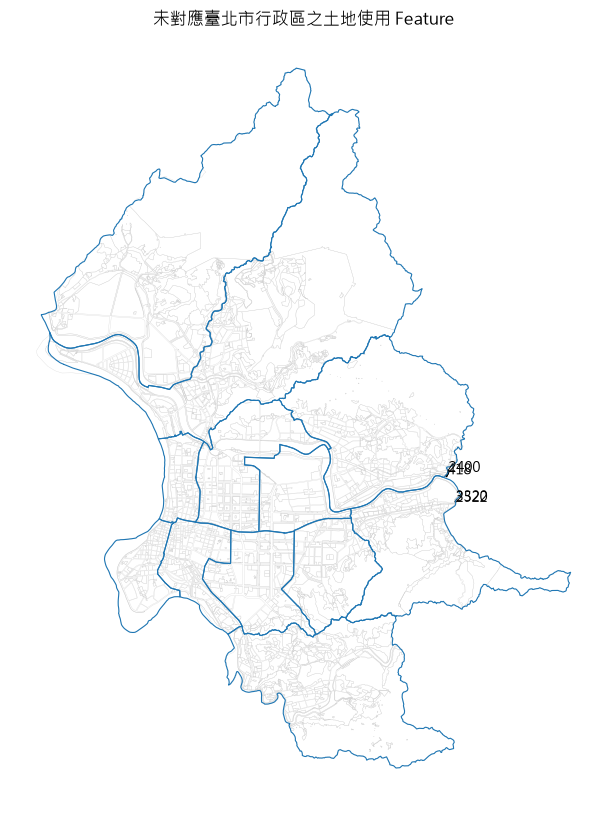

In [79]:
#把4筆資料畫在行政區界上
import matplotlib.pyplot as plt

fig_unfeature, ax = plt.subplots(figsize=(10, 10))

# 行政區界
district.boundary.plot(
    ax=ax,
    linewidth=0.8
)

# 全部土地使用淡淡當背景
landuse_analytical.plot(
    ax=ax,
    facecolor="none",
    edgecolor="lightgray",
    linewidth=0.2
)

# 4 筆未對應 feature
unmatched_district_features.plot(
    ax=ax,
    facecolor="red",
    edgecolor="black",
    linewidth=1.2
)

for _, row in unmatched_district_features.iterrows():
    p = row.geometry.representative_point()
    ax.text(
        p.x,
        p.y,
        row["編號"],
        fontsize=10
    )

ax.set_title("未對應臺北市行政區之土地使用 Feature")
ax.set_axis_off()

plt.show()

In [80]:
# ==========================================
# Task 10-C3
# 找出未匹配 feature 最近的行政區與距離
# 修正版
# ==========================================

# 1. 複製未匹配 features
unmatched_for_nearest = unmatched_district_features.copy()

# 2. 如果前一次 spatial join 留下 index_right，先移除
if "index_right" in unmatched_for_nearest.columns:
    unmatched_for_nearest = unmatched_for_nearest.drop(
        columns=["index_right"]
    )


# 3. 準備行政區資料
district_nearest = (
    district[
        ["TNAME", "geometry"]
    ]
    .rename(
        columns={
            "TNAME": "nearest_district"
        }
    )
    .copy()
)


# 4. Spatial Join Nearest
nearest_check = unmatched_for_nearest.sjoin_nearest(
    district_nearest,
    how="left",
    distance_col="distance_to_district_m"
)


# 5. 顯示結果
print("=== 未匹配 Feature 最近行政區 ===")

print(
    nearest_check[
        [
            "編號",
            "使用分區",
            "main_category",
            "area_m2",
            "nearest_district",
            "distance_to_district_m"
        ]
    ].to_string(index=False)
)

=== 未匹配 Feature 最近行政區 ===
  編號   使用分區 main_category     area_m2 nearest_district  distance_to_district_m
 418    河川區          水域水利 1935.609912              內湖區               10.329512
2400 高速公路用地          交通運輸  109.845361              內湖區               11.090255
2522   堤防用地          水域水利    3.921477              南港區                3.510113
3320   堤防用地          水域水利    0.300069              南港區                5.495156


關於這4筆資料的歸屬：雖然距離只有 3–11 m，但我們沒有官方依據說應該把它們自動補進內湖區或南港區。

所以在行政區分析中 → 保留這 4 筆於市級 land-use dataset，但在 district-level intersection 中自然排除。

並在方法說明記錄 → 4 筆土地使用 feature 因來源圖層邊界差異，位於行政區界外約 3–11 m，故不進行最近行政區強制配對。

In [81]:
# ==========================================
# Task 10-D
# Administrative District × Land Use Intersect
# ==========================================

# 1. 準備行政區分析圖層
district_analysis = (
    district[
        ["TNAME", "geometry"]
    ]
    .rename(
        columns={
            "TNAME": "district_name"
        }
    )
    .copy()
)


# 2. Polygon Intersection
landuse_by_district = landuse_analytical.overlay(
    district_analysis,
    how="intersection",
    keep_geom_type=True
)


# 3. QA
print("=== District × Land Use Intersect QA ===")

print("原土地使用 features：", len(landuse_analytical))
print("Intersect 後 features：", len(landuse_by_district))

print("\nGeometry types：")
print(
    landuse_by_district.geometry
    .geom_type
    .value_counts()
)

print(
    "\nInvalid geometry：",
    (~landuse_by_district.geometry.is_valid).sum()
)

print(
    "Empty geometry：",
    landuse_by_district.geometry.is_empty.sum()
)

print(
    "Missing district_name：",
    landuse_by_district["district_name"].isna().sum()
)

=== District × Land Use Intersect QA ===
原土地使用 features： 3832
Intersect 後 features： 4022

Geometry types：
Polygon         3919
MultiPolygon     103
Name: count, dtype: int64

Invalid geometry： 0
Empty geometry： 0
Missing district_name： 0


In [82]:
# ==========================================
# Task 10-E 重新計算切割後的面積
# Recalculate area after intersection
# ==========================================

landuse_by_district["area_m2"] = (
    landuse_by_district.geometry.area
)

landuse_by_district["area_km2"] = (
    landuse_by_district["area_m2"]
    / 1_000_000
)

In [83]:
#Task 10-F 建立｢行政區x土地使用」面積表
district_landuse_summary = (
    landuse_by_district
    .groupby(
        ["district_name", "main_category"]
    )
    .agg(
        area_km2=("area_km2", "sum")
    )
    .reset_index()
)

In [84]:
#Task 10-G 計算每個行政區內部的土地使用比例
district_landuse_summary["district_total_km2"] = (
    district_landuse_summary
    .groupby("district_name")["area_km2"]
    .transform("sum")
)

district_landuse_summary["district_pct"] = (
    district_landuse_summary["area_km2"]
    / district_landuse_summary["district_total_km2"]
    * 100
)

In [85]:
# Task 10-H 每區前三大土地使用

district_top3 = (
    district_landuse_summary
    .sort_values(
        ["district_name", "area_km2"],
        ascending=[True, False]
    )
    .groupby("district_name")
    .head(3)
    .reset_index(drop=True)
)

print("=== 各行政區前三大土地使用類別 ===")

print(
    district_top3[
        [
            "district_name",
            "main_category",
            "area_km2",
            "district_pct"
        ]
    ].to_string(
        index=False,
        formatters={
            "area_km2": "{:.3f}".format,
            "district_pct": "{:.2f}%".format
        }
    )
)

=== 各行政區前三大土地使用類別 ===
district_name main_category area_km2 district_pct
          中山區            住宅    3.025       24.80%
          中山區          商業服務    2.277       18.67%
          中山區          保護保育    1.938       15.89%
          中正區            住宅    2.103       35.19%
          中正區          商業服務    0.839       14.04%
          中正區        公共行政服務    0.631       10.55%
          信義區          保護保育    3.969       38.03%
          信義區            住宅    3.197       30.64%
          信義區          特殊專用    1.194       11.44%
          內湖區          保護保育   16.021       52.85%
          內湖區            住宅    4.763       15.71%
          內湖區        公園綠地遊憩    2.649        8.74%
          北投區          保護保育   34.100       60.79%
          北投區            住宅    6.434       11.47%
          北投區            農業    5.002        8.92%
          南港區          保護保育   11.774       55.78%
          南港區        公共行政服務    2.517       11.93%
          南港區            住宅    1.517        7.19%
          士林區          保護保育 

In [86]:
# ==========================================
# Task 10-I 12行政區百分之百堆疊長條圖
# 12 行政區土地使用組成 100% Stacked Bar
# ==========================================

district_pct_pivot = (
    district_landuse_summary
    .pivot(
        index="district_name",
        columns="main_category",
        values="district_pct"
    )
    .fillna(0)
)

print(district_pct_pivot.head())

main_category      交通運輸         住宅       保護保育    公共事業設施     公共行政服務    公園綠地遊憩  \
district_name                                                                  
中山區            3.813699  24.804478  15.887377  1.081410   6.166426  7.659450   
中正區            2.047046  35.188468   1.478009  2.760075  10.553897  7.400709   
信義區            1.914322  30.636048  38.032657  0.036579   3.215904  3.732074   
內湖區            1.920370  15.712598  52.847331  1.029989   2.169811  8.739316   
北投區            1.235926  11.469129  60.790597  0.282345   1.753272  5.318362   

main_category       商業服務      工業產業    文化宗教保存         文教        殯葬       水域水利  \
district_name                                                                  
中山區            18.670542  1.672250  0.422862   4.268645  0.174627  14.026379   
中正區            14.041235  0.771448  6.735651  10.374196  0.000000   8.091819   
信義區             3.869405  2.030690  0.137214   4.685605  0.000357   0.273225   
內湖區             1.478185  8.592154  0.0

In [87]:
# 固定行政區順序
district_order = [
    "北投區", "士林區", "內湖區", "南港區",
    "文山區", "信義區", "松山區", "中山區",
    "大安區", "中正區", "大同區", "萬華區"
]

district_pct_pivot = district_pct_pivot.reindex(
    district_order
)

In [88]:
#固定類別順序
category_order = [
    "住宅",
    "商業服務",
    "工業產業",
    "文教",
    "公共行政服務",
    "公共事業設施",
    "交通運輸",
    "公園綠地遊憩",
    "水域水利",
    "農業",
    "保護保育",
    "文化宗教保存",
    "殯葬",
    "特殊專用"
]

district_pct_pivot = district_pct_pivot.reindex(
    columns=category_order,
    fill_value=0
)

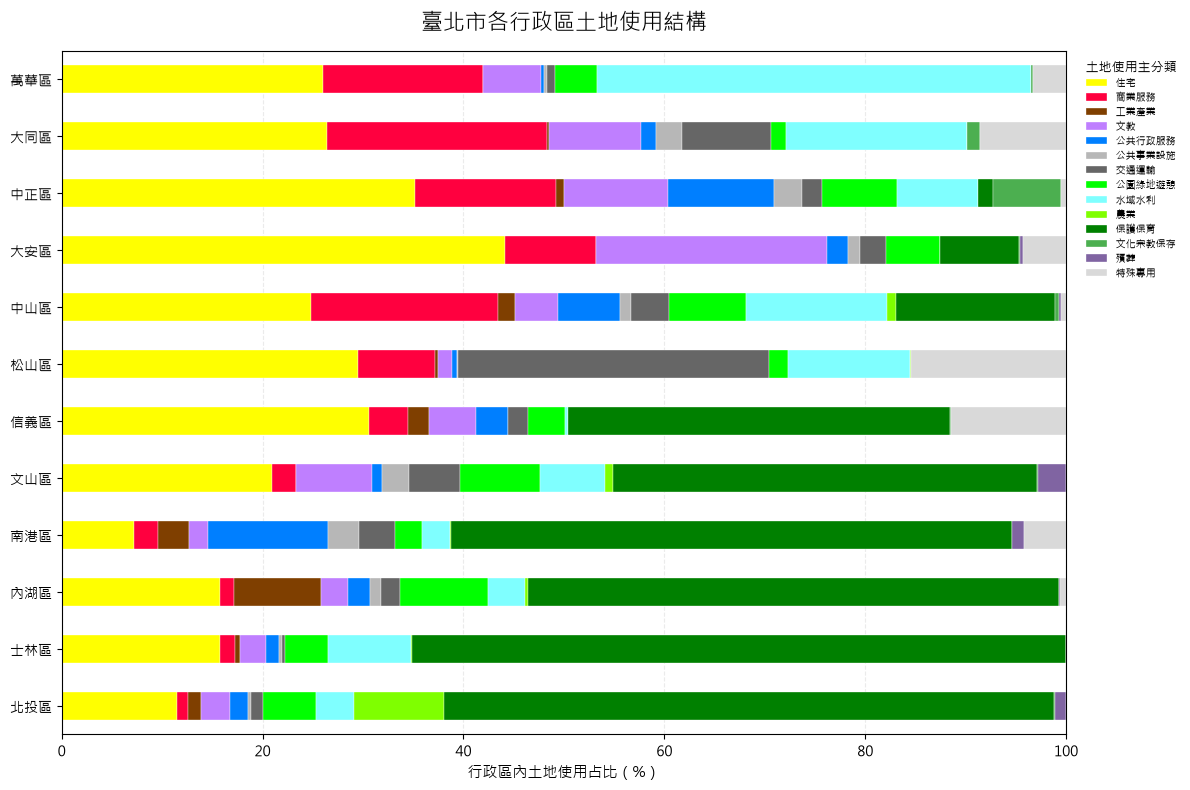

In [89]:
#設定顏色
stack_colors = [
    category_colors[category]
    for category in category_order
]

#畫百分百堆疊長條圖
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Microsoft JhengHei"
plt.rcParams["axes.unicode_minus"] = False

fig_stack, ax = plt.subplots(figsize=(12, 8))

district_pct_pivot.plot(
    kind="barh",
    stacked=True,
    ax=ax,
    color=stack_colors,
    edgecolor="white",
    linewidth=0.25
)

ax.set_title(
    "臺北市各行政區土地使用結構",
    fontsize=16,
    pad=15
)

ax.set_xlabel(
    "行政區內土地使用占比（%）",
    fontsize=11
)

ax.set_ylabel("")
ax.set_xlim(0, 100)

ax.legend(
    title="土地使用主分類",
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    frameon=False,
    fontsize=7.5,
    title_fontsize=9,
    labelspacing=0.4
)

ax.xaxis.grid(
    True,
    linestyle="--",
    alpha=0.25
)

ax.set_axisbelow(True)

plt.tight_layout()

plt.show()

In [90]:
# Task 10-J 各區主導之土地使用表
district_dominant = (
    district_landuse_summary
    .sort_values(
        ["district_name", "district_pct"],
        ascending=[True, False]
    )
    .groupby("district_name")
    .head(1)
    .reset_index(drop=True)
)

print("=== 各行政區主導土地使用 ===")

print(
    district_dominant[
        [
            "district_name",
            "main_category",
            "district_pct"
        ]
    ].to_string(
        index=False,
        formatters={
            "district_pct": "{:.2f}%".format
        }
    )
)

=== 各行政區主導土地使用 ===
district_name main_category district_pct
          中山區            住宅       24.80%
          中正區            住宅       35.19%
          信義區          保護保育       38.03%
          內湖區          保護保育       52.85%
          北投區          保護保育       60.79%
          南港區          保護保育       55.78%
          士林區          保護保育       65.09%
          大同區            住宅       26.39%
          大安區            住宅       44.11%
          文山區          保護保育       42.26%
          松山區          交通運輸       30.98%
          萬華區          水域水利       43.15%


In [91]:
# Task 10-K 輸出行政區分析成果
# 詳細行政區土地使用統計
district_landuse_summary.to_csv(
    tables_dir / "district_landuse_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

# 各區前三大
district_top3.to_csv(
    tables_dir / "district_top3_landuse.csv",
    index=False,
    encoding="utf-8-sig"
)

# Intersect 後 GIS layer
landuse_by_district.to_file(
    processed_dir / "landuse_by_district.gpkg",
    layer="landuse_by_district",
    driver="GPKG"
)

In [92]:
fig_stack.savefig(
    maps_dir / "district_landuse_composition.png",
    dpi=300,
    bbox_inches="tight"
)

Task 11 buffer(環域分析) + intersect(兩個不同的圖資，在空間上共同重覆的部分擷取出來，並在屬性資料中保留兩圖層各自的屬性於結果圖層中。)
捷運站800公尺步行服務範圍內的土地使用結構
Point
→ Buffer
→ Dissolve(整合同屬性分區)
→ Intersect
→ Area calculation
→ Land-use composition

In [93]:
import geopandas as gpd
import pandas as pd
from pathlib import Path

# 自動判斷路徑（無論工作目錄在專案根目錄還是 src/ 都可正確讀取）
base_dir = Path.cwd()
data_path = base_dir / "data" / "MRT_stations" / "MRT_stations.shp"
if not data_path.exists():
    data_path = base_dir.parent / "data" / "MRT_stations" / "MRT_stations.shp"

print(f"讀取資料路徑: {data_path.resolve()}")
MRT = gpd.read_file(data_path, encoding="utf-8")
MRT = MRT.set_crs(epsg=3826)
print("資料數量與欄位：", MRT.shape)
MRT.head()

讀取資料路徑: C:\Users\RollyHe\Desktop\Project\taipei_urban_gis\data\MRT_stations\MRT_stations.shp
資料數量與欄位： (802, 11)


,OBJECTID,MARKID,MARKTYPE1,MARKTYPE2,MARKNAME1,MARKNAME2,UPD_YYYYMM,ADDRESS,TEL,EPSGCode,geometry
0,1,F0000003224,9960103,None,臺北捷運三民高中站-出入口1,北捷三民高中站-出入口1,202201,新北市蘆洲區三民路、復興路口，近三民停車場,NaN,EPSG:3826,POINT (297675.451 2775348.767)
1,2,F0000016785,9960103,None,新北捷運中和站_Y12,新北捷中和站_Y12,202405,新北市中和區中山路二段271號,02-218-12345,EPSG:3826,POINT (300071.354 2766129.155)
2,3,F0000001263,9960103,None,桃園機場捷運泰山貴和站_A6,機捷泰山貴和站_A6,202205,新北市泰山區新北大道六段460號,(03)286-8789,EPSG:3826,POINT (292656.539 2769518.061)
3,4,F0000011654,9960103,None,臺北捷運南勢角站-出入口1,北捷南勢角站-出入口1,202201,新北市中和區捷運路52號、近南山路399巷,NaN,EPSG:3826,POINT (301259.178 2764841.786)
4,5,F0000001228,9960103,None,臺北捷運丹鳳站-出入口2,北捷丹鳳站-出入口2,201904,新北市新莊區中正路、近民安路口,NaN,EPSG:3826,POINT (292650.026 2769019.957)


In [94]:
print("=== MRT Dataset QA ===")

print("Shape:")
print(MRT.shape)

print("\nColumns:")
print(MRT.columns)

print("\nCRS:")
print(MRT.crs)

print("\nGeometry types:")
print(
    MRT.geometry
    .geom_type
    .value_counts()
)

print("\nInvalid geometry:")
print(
    (~MRT.geometry.is_valid).sum()
)

print("\nEmpty geometry:")
print(
    MRT.geometry.is_empty.sum()
)

=== MRT Dataset QA ===
Shape:
(802, 11)

Columns:
Index(['OBJECTID', 'MARKID', 'MARKTYPE1', 'MARKTYPE2', 'MARKNAME1',
       'MARKNAME2', 'UPD_YYYYMM', 'ADDRESS', 'TEL', 'EPSGCode', 'geometry'],
      dtype='str')

CRS:
EPSG:3826

Geometry types:
Point    802
Name: count, dtype: int64

Invalid geometry:
0

Empty geometry:
0


In [95]:
# ==========================================
# Task 11-A
# MRT Point Attribute Audit
# ==========================================

print("=== MARKTYPE1 ===")
print(
    MRT["MARKTYPE1"]
    .value_counts(dropna=False)
)

print("\n=== MARKTYPE2 ===")
print(
    MRT["MARKTYPE2"]
    .value_counts(dropna=False)
)

print("\n=== MARKNAME1 Sample ===")
print(
    MRT["MARKNAME1"]
    .dropna()
    .drop_duplicates()
    .head(30)
    .to_string(index=False)
)

print("\n=== MARKNAME2 Sample ===")
print(
    MRT["MARKNAME2"]
    .dropna()
    .drop_duplicates()
    .head(30)
    .to_string(index=False)
)

=== MARKTYPE1 ===
MARKTYPE1
9960103    802
Name: count, dtype: int64

=== MARKTYPE2 ===
MARKTYPE2
None    802
Name: count, dtype: int64

=== MARKNAME1 Sample ===
    臺北捷運三民高中站-出入口1
       新北捷運中和站_Y12
    桃園機場捷運泰山貴和站_A6
     臺北捷運南勢角站-出入口1
      臺北捷運丹鳳站-出入口2
    臺北捷運亞東醫院站-出入口1
      臺北捷運輔大站-出入口3
      臺北捷運海山站-出入口2
      臺北捷運頂埔站-出入口4
     臺北捷運三重國小站_O50
桃園機場捷運新北產業園區站-出入口1
      臺北捷運三重站-出入口3
  桃園機場捷運泰山貴和站-出入口1
       臺北捷運菜寮站_O14
      臺北捷運新埔站-出入口3
   桃園機場捷運泰山站--出入口3
     臺北捷運江子翠站-出入口2
      臺北捷運永寧站-出入口1
       新北捷運中原站_Y14
      臺北捷運頂埔站-出入口1
      臺北捷運土城站-出入口3
     臺北捷運紅樹林站-出入口2
      臺北捷運輔大站-出入口1
       新北捷運板新站-出入口
       臺北捷運三重站_O15
     臺北捷運頭前庄站-出入口3
       臺北捷運竹圍站_R26
    桃園機場捷運泰山站-出入口1
 桃園機場捷運新莊副都心站-出入口1
     臺北捷運紅樹林站-出入口1

=== MARKNAME2 Sample ===
  北捷三民高中站-出入口1
    新北捷中和站_Y12
    機捷泰山貴和站_A6
   北捷南勢角站-出入口1
    北捷丹鳳站-出入口2
  北捷亞東醫院站-出入口1
    北捷輔大站-出入口3
    北捷海山站-出入口2
    北捷頂埔站-出入口4
   北捷三重國小站_O50
機捷新北產業園區站-出入口1
    北捷三重站-出入口3
  機捷泰山貴和站-出入口1
     北捷菜寮站_O14
    北捷新埔站-出入口3
    機捷泰山站-出入口3
  

Task 11-B 建立台北市境內捷運出入口分析點位
－以位於臺北市行政界內之捷運出入口為中心，建立 800 公尺 Euclidean Buffer，分析其涵蓋之土地使用結構。

In [96]:
# ==========================================
# Task 11-B1
# Extract MRT entrances
# ==========================================

MRT_entrances = MRT.loc[
    MRT["MARKNAME1"]
    .str.contains("出入口", na=False)
].copy()

print("MRT 全部點位：", len(MRT))
print("出入口點位：", len(MRT_entrances))

print(
    MRT_entrances[
        ["MARKNAME1", "ADDRESS"]
    ].head(20)
)

MRT 全部點位： 802
出入口點位： 587
             MARKNAME1                  ADDRESS
0       臺北捷運三民高中站-出入口1    新北市蘆洲區三民路、復興路口，近三民停車場
3        臺北捷運南勢角站-出入口1    新北市中和區捷運路52號、近南山路399巷
4         臺北捷運丹鳳站-出入口2          新北市新莊區中正路、近民安路口
5       臺北捷運亞東醫院站-出入口1         新北市板橋區南雅南路二段120號
6         臺北捷運輔大站-出入口3        新北市新莊區中正路、中油加油站對面
7         臺北捷運海山站-出入口2       新北市土城區海山路、新北高工運動場旁
8         臺北捷運頂埔站-出入口4          新北市土城區中央路四段62號旁
10  桃園機場捷運新北產業園區站-出入口1             新北市新莊區五工路37號
11        臺北捷運三重站-出入口3       新北市三重區捷運路、近捷運路19巷口
12    桃園機場捷運泰山貴和站-出入口1         新北市泰山區新北大道六段460號
14        臺北捷運新埔站-出入口3         新北市板橋區民生路二段234巷口
15     桃園機場捷運泰山站--出入口3         新北市泰山區新北大道四段431號
16       臺北捷運江子翠站-出入口2          新北市板橋區文化路二段313號
17        臺北捷運永寧站-出入口1          新北市土城區中央路三段98巷口
19        臺北捷運頂埔站-出入口1        新北市土城區中央路四段約100號旁
20        臺北捷運土城站-出入口3              新北市土城區金城路一段
21       臺北捷運紅樹林站-出入口2  新北市淡水區自行車步道紅樹林段、近紅樹林教育館
22        臺北捷運輔大站-出入口1    新北市新莊區中正路510之1號、近輔大校門
23         新北捷運板新站-出入口            新北市板橋區板新路109號
25       臺北捷運頭前

In [97]:
# ==========================================
# Task 11-B2
# Build Taipei City boundary
# ==========================================

taipei_boundary = (
    district[
        ["geometry"]
    ]
    .dissolve()
    .reset_index(drop=True)
)

print("臺北市 boundary features：", len(taipei_boundary))
print("CRS：", taipei_boundary.crs)
print("Geometry type：", taipei_boundary.geometry.geom_type.iloc[0])

臺北市 boundary features： 1
CRS： EPSG:3826
Geometry type： Polygon


In [98]:
# ==========================================
# Task 11-B3
# Keep entrances located within Taipei City
# ==========================================

MRT_entrances_taipei = MRT_entrances.sjoin(
    taipei_boundary,
    how="inner",
    predicate="intersects"
)

# 移除 sjoin 自動產生的 index_right
MRT_entrances_taipei = (
    MRT_entrances_taipei
    .drop(columns=["index_right"], errors="ignore")
    .copy()
)

print("全部捷運出入口：", len(MRT_entrances))
print("臺北市境內捷運出入口：", len(MRT_entrances_taipei))

全部捷運出入口： 587
臺北市境內捷運出入口： 284


In [99]:
system_summary = {
    "臺北捷運": MRT_entrances_taipei["MARKNAME1"]
        .str.startswith("臺北捷運")
        .sum(),

    "新北捷運": MRT_entrances_taipei["MARKNAME1"]
        .str.startswith("新北捷運")
        .sum(),

    "桃園機場捷運": MRT_entrances_taipei["MARKNAME1"]
        .str.startswith("桃園機場捷運")
        .sum()
}

print("=== 臺北市境內各捷運系統出入口 ===")

for system, count in system_summary.items():
    print(system, count)

=== 臺北市境內各捷運系統出入口 ===
臺北捷運 277
新北捷運 0
桃園機場捷運 7


Task 11-C 建立800m buffer

In [100]:
# ==========================================
# Task 11-C
# 800 m Entrance Buffer
# ==========================================

MRT_buffer_800 = MRT_entrances_taipei[
    ["MARKID", "MARKNAME1", "MARKNAME2", "geometry"]
].copy()

MRT_buffer_800["geometry"] = (
    MRT_buffer_800.geometry.buffer(800)
)

print("Buffer features：", len(MRT_buffer_800))

print(
    "Geometry types："
)

print(
    MRT_buffer_800.geometry
    .geom_type
    .value_counts()
)

print(
    "Invalid geometry：",
    (~MRT_buffer_800.geometry.is_valid).sum()
)

Buffer features： 284
Geometry types：
Polygon    284
Name: count, dtype: int64
Invalid geometry： 0


In [101]:
# ==========================================
# Task 11-D
# Dissolve overlapping entrance buffers
# ==========================================

MRT_buffer_800_dissolved = (
    MRT_buffer_800[
        ["geometry"]
    ]
    .dissolve()
    .reset_index(drop=True)
)

print(
    "Dissolved buffer features：",
    len(MRT_buffer_800_dissolved)
)

print(
    "Geometry type：",
    MRT_buffer_800_dissolved.geometry.geom_type.iloc[0]
)

print(
    "Invalid：",
    (~MRT_buffer_800_dissolved.geometry.is_valid).sum()
)

Dissolved buffer features： 1
Geometry type： Polygon
Invalid： 0


In [102]:
MRT_buffer_800_dissolved["area_m2"] = (
    MRT_buffer_800_dissolved.geometry.area
)

MRT_buffer_800_dissolved["area_km2"] = (
    MRT_buffer_800_dissolved["area_m2"]
    / 1_000_000
)

print(
    "800m Buffer unique coverage：",
    MRT_buffer_800_dissolved["area_km2"].iloc[0],
    "km²"
)

800m Buffer unique coverage： 94.40304234249867 km²


In [103]:
# ==========================================
# Task 11-F
# Clip 800m coverage to Taipei City
# ==========================================

MRT_buffer_800_taipei = (
    MRT_buffer_800_dissolved
    .overlay(
        taipei_boundary,
        how="intersection"
    )
)

MRT_buffer_800_taipei["area_m2"] = (
    MRT_buffer_800_taipei.geometry.area
)

MRT_buffer_800_taipei["area_km2"] = (
    MRT_buffer_800_taipei["area_m2"]
    / 1_000_000
)

print(
    "臺北市內 MRT 800m coverage：",
    MRT_buffer_800_taipei["area_km2"].sum(),
    "km²"
)

臺北市內 MRT 800m coverage： 91.52344787599324 km²


Task 11-G MRT 800m x 土地使用intersect

In [104]:
# ==========================================
# Task 11-G
# MRT 800m Coverage × Main Category Land Use
# ==========================================

mrt_landuse_intersection = (
    landuse_dissolved[
        ["main_category", "geometry"]
    ]
    .overlay(
        MRT_buffer_800_taipei[["geometry"]],
        how="intersection",
        keep_geom_type=True
    )
)

print("=== MRT 800m × Land Use Intersect QA ===")

print(
    "Intersect features：",
    len(mrt_landuse_intersection)
)

print("\nGeometry types：")
print(
    mrt_landuse_intersection.geometry
    .geom_type
    .value_counts()
)

print(
    "\nInvalid geometry：",
    (~mrt_landuse_intersection.geometry.is_valid).sum()
)

print(
    "Empty geometry：",
    mrt_landuse_intersection.geometry.is_empty.sum()
)

print(
    "Missing main_category：",
    mrt_landuse_intersection["main_category"].isna().sum()
)

=== MRT 800m × Land Use Intersect QA ===
Intersect features： 14

Geometry types：
MultiPolygon    14
Name: count, dtype: int64

Invalid geometry： 0
Empty geometry： 0
Missing main_category： 0


In [105]:
#重新計算intersect面積
mrt_landuse_intersection["area_m2"] = (
    mrt_landuse_intersection.geometry.area
)

mrt_landuse_intersection["area_km2"] = (
    mrt_landuse_intersection["area_m2"]
    / 1_000_000
)
#建立MRT 800m內土地使用面積表
mrt_landuse_summary = (
    mrt_landuse_intersection
    .groupby("main_category")
    .agg(
        mrt_area_km2=("area_km2", "sum")
    )
    .reset_index()
)
#計算800m範圍內土地使用組成
total_mrt_landuse_area = (
    mrt_landuse_summary["mrt_area_km2"].sum()
)

mrt_landuse_summary["mrt_composition_pct"] = (
    mrt_landuse_summary["mrt_area_km2"]
    / total_mrt_landuse_area
    * 100
)
#排序
mrt_landuse_summary = (
    mrt_landuse_summary
    .sort_values(
        "mrt_area_km2",
        ascending=False
    )
    .reset_index(drop=True)
)

#輸出
print("=== MRT 800m 範圍內土地使用組成 ===")

print(
    mrt_landuse_summary.to_string(
        index=False,
        formatters={
            "mrt_area_km2": "{:.3f}".format,
            "mrt_composition_pct": "{:.2f}%".format
        }
    )
)

print(
    f"\nMRT 800m 範圍內土地使用面積合計："
    f"{total_mrt_landuse_area:.3f} km²"
)

=== MRT 800m 範圍內土地使用組成 ===
main_category mrt_area_km2 mrt_composition_pct
           住宅       29.291              36.25%
         商業服務        9.007              11.15%
           文教        7.382               9.14%
       公園綠地遊憩        7.181               8.89%
         保護保育        6.393               7.91%
         水域水利        4.390               5.43%
         特殊專用        3.955               4.89%
       公共行政服務        3.582               4.43%
         交通運輸        3.475               4.30%
         工業產業        2.590               3.21%
           農業        2.415               2.99%
       文化宗教保存        0.537               0.66%
       公共事業設施        0.525               0.65%
           殯葬        0.075               0.09%

MRT 800m 範圍內土地使用面積合計：80.798 km²


Task 11-I 各土地使用類別的MRT Coverage Rate 
各類土地使用，有多少比例落在捷運出入口800m內

In [106]:
#把全市面積接起來
mrt_coverage_summary = (
    final_area_summary[
        ["main_category", "area_km2"]
    ]
    .rename(
        columns={
            "area_km2": "city_area_km2"
        }
    )
    .merge(
        mrt_landuse_summary[
            ["main_category", "mrt_area_km2"]
        ],
        on="main_category",
        how="left"
    )
)

#算coverage %
mrt_coverage_summary["mrt_coverage_pct"] = (
    mrt_coverage_summary["mrt_area_km2"]
    / mrt_coverage_summary["city_area_km2"]
    * 100
)

#排序
mrt_coverage_summary = (
    mrt_coverage_summary
    .sort_values(
        "mrt_coverage_pct",
        ascending=False
    )
    .reset_index(drop=True)
)
#輸出
print("=== 各土地使用類別 MRT 800m Coverage ===")

print(
    mrt_coverage_summary.to_string(
        index=False,
        formatters={
            "city_area_km2": "{:.3f}".format,
            "mrt_area_km2": "{:.3f}".format,
            "mrt_coverage_pct": "{:.2f}%".format
        }
    )
)

=== 各土地使用類別 MRT 800m Coverage ===
main_category city_area_km2 mrt_area_km2 mrt_coverage_pct
         商業服務        10.066        9.007           89.48%
         特殊專用         4.571        3.955           86.51%
       文化宗教保存         0.626        0.537           85.82%
           文教        11.406        7.382           64.72%
           住宅        45.962       29.291           63.73%
         工業產業         4.755        2.590           54.48%
       公園綠地遊憩        13.846        7.181           51.86%
       公共行政服務         7.260        3.582           49.34%
         交通運輸         7.695        3.475           45.16%
           農業         5.507        2.415           43.85%
         水域水利        18.104        4.390           24.25%
       公共事業設施         2.619        0.525           20.03%
         保護保育       119.951        6.393            5.33%
           殯葬         1.812        0.075            4.13%


Task 11-J 整體MRT coverage指標

In [107]:
total_city_landuse_area = (
    final_area_summary["area_km2"].sum()
)

overall_mrt_coverage_pct = (
    total_mrt_landuse_area
    / total_city_landuse_area
    * 100
)

print("=== Overall MRT 800m Land-use Coverage ===")

print(
    f"全市土地使用資料面積："
    f"{total_city_landuse_area:.3f} km²"
)

print(
    f"MRT 800m 內土地使用面積："
    f"{total_mrt_landuse_area:.3f} km²"
)

print(
    f"MRT 800m Coverage："
    f"{overall_mrt_coverage_pct:.2f}%"
)

=== Overall MRT 800m Land-use Coverage ===
全市土地使用資料面積：254.179 km²
MRT 800m 內土地使用面積：80.798 km²
MRT 800m Coverage：31.79%


Task 11-K 畫Coverage rate長條圖

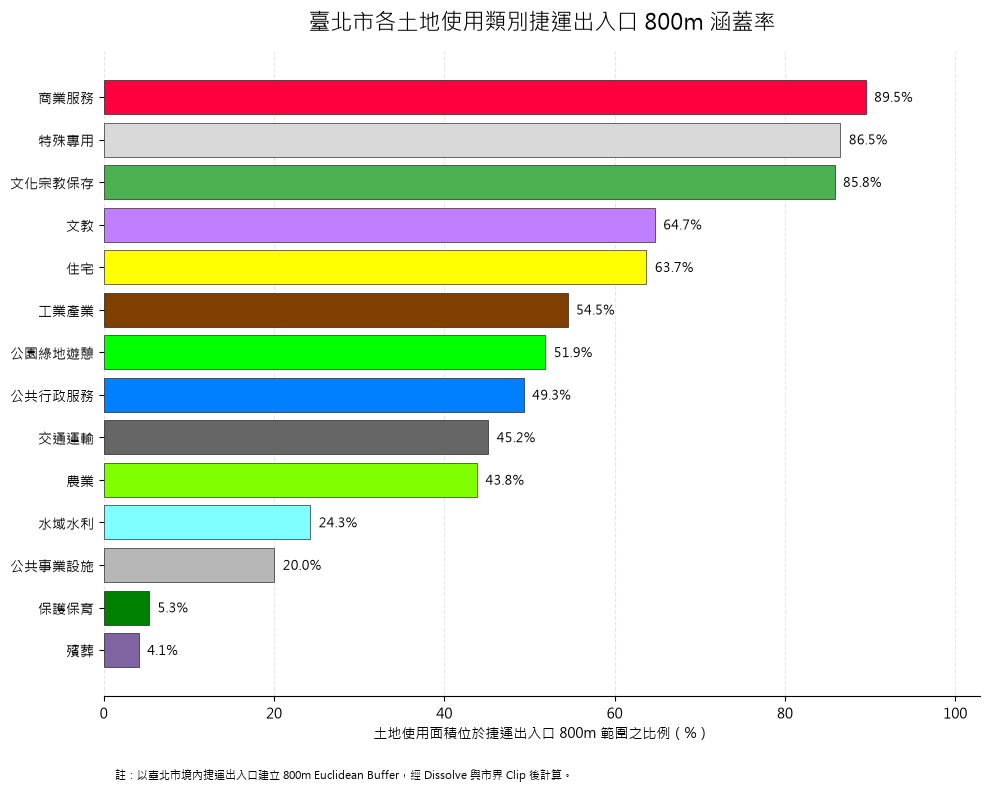

In [108]:
# ==========================================
# Task 11-K
# MRT 800m Coverage Rate Bar Chart
# ==========================================

import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Microsoft JhengHei"
plt.rcParams["axes.unicode_minus"] = False


plot_mrt = (
    mrt_coverage_summary
    .sort_values(
        "mrt_coverage_pct",
        ascending=True
    )
    .copy()
)

bar_colors = (
    plot_mrt["main_category"]
    .map(category_colors)
)


fig_mrt, ax = plt.subplots(
    figsize=(10, 8)
)

bars = ax.barh(
    plot_mrt["main_category"],
    plot_mrt["mrt_coverage_pct"],
    color=bar_colors,
    edgecolor="black",
    linewidth=0.4
)


# 數值標籤
for bar, pct in zip(
    bars,
    plot_mrt["mrt_coverage_pct"]
):

    ax.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{pct:.1f}%",
        va="center",
        fontsize=9
    )


ax.set_title(
    "臺北市各土地使用類別捷運出入口 800m 涵蓋率",
    fontsize=16,
    pad=15
)

ax.set_xlabel(
    "土地使用面積位於捷運出入口 800m 範圍之比例（%）",
    fontsize=10
)

ax.set_ylabel("")

ax.set_xlim(
    0,
    min(
        105,
        plot_mrt["mrt_coverage_pct"].max() * 1.15
    )
)

ax.xaxis.grid(
    True,
    linestyle="--",
    alpha=0.3
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

fig_mrt.text(
    0.12,
    0.02,
    "註：以臺北市境內捷運出入口建立 800m Euclidean Buffer，"
    "經 Dissolve 與市界 Clip 後計算。",
    fontsize=8,
    ha="left"
)

plt.tight_layout(
    rect=[0, 0.05, 1, 1]
)

plt.show()

In [109]:
mrt_landuse_summary.to_csv(
    tables_dir / "mrt_800m_landuse_composition.csv",
    index=False,
    encoding="utf-8-sig"
)

mrt_coverage_summary.to_csv(
    tables_dir / "mrt_800m_landuse_coverage.csv",
    index=False,
    encoding="utf-8-sig"
)

MRT_buffer_800_taipei.to_file(
    processed_dir / "mrt_800m_coverage.gpkg",
    layer="mrt_800m_coverage",
    driver="GPKG"
)

fig_mrt.savefig(
    maps_dir / "mrt_800m_landuse_coverage.png",
    dpi=300,
    bbox_inches="tight"
)

Task 12 Python → PostGIS

In [110]:
from pathlib import Path
from dotenv import load_dotenv
import os

project_root = Path("..")
env_path = project_root / ".env"

load_dotenv(env_path)

DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")

print("DB_HOST:", DB_HOST)
print("DB_PORT:", DB_PORT)
print("DB_NAME:", DB_NAME)
print("DB_USER:", DB_USER)
print("DB_PASSWORD loaded:", DB_PASSWORD is not None)

DB_HOST: localhost
DB_PORT: 5432
DB_NAME: taipei_gis
DB_USER: postgres
DB_PASSWORD loaded: True


In [111]:
from sqlalchemy import create_engine, text

engine = create_engine(
    f"postgresql+psycopg2://"
    f"{DB_USER}:{DB_PASSWORD}"
    f"@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

In [112]:
with engine.connect() as conn:
    result = conn.execute(
        text("SELECT PostGIS_Version();")
    )

    print("PostGIS Version:", result.scalar())

PostGIS Version: 3.6 USE_GEOS=1 USE_PROJ=1 USE_STATS=1


In [113]:
#建立專案schema
with engine.begin() as conn:
    conn.execute(
        text("""
        CREATE SCHEMA IF NOT EXISTS taipei_landuse;
        """)
    )

print("Schema ready.")

Schema ready.


In [114]:
#先上傳landuse_analytical至postgis
landuse_analytical.to_postgis(
    name="landuse_analytical",
    con=engine,
    schema="taipei_landuse",
    if_exists="replace",
    index=False
)

print("landuse_analytical uploaded successfully.")

landuse_analytical uploaded successfully.


In [115]:
#使用SQL回查QA
qa_query = """
SELECT
    COUNT(*) AS feature_count,
    ST_SRID(geometry) AS srid,
    GeometryType(geometry) AS geom_type
FROM taipei_landuse.landuse_analytical
GROUP BY
    ST_SRID(geometry),
    GeometryType(geometry);
"""

with engine.connect() as conn:
    result = conn.execute(text(qa_query))

    for row in result:
        print(row)

(3825, 3826, 'POLYGON')
(7, 3826, 'MULTIPOLYGON')


In [116]:
#將其他的圖層傳至PostGIS
landuse_dissolved.to_postgis(
    name="landuse_dissolved",
    con=engine,
    schema="taipei_landuse",
    if_exists="replace",
    index=False
)

district.to_postgis(
    name="district",
    con=engine,
    schema="taipei_landuse",
    if_exists="replace",
    index=False
)

MRT_entrances_taipei.to_postgis(
    name="mrt_entrances_taipei",
    con=engine,
    schema="taipei_landuse",
    if_exists="replace",
    index=False
)

MRT_buffer_800_taipei.to_postgis(
    name="mrt_800m_coverage",
    con=engine,
    schema="taipei_landuse",
    if_exists="replace",
    index=False
)

print("All core spatial layers uploaded.")

All core spatial layers uploaded.


In [117]:
from geometry_utils import (
    repair_geometry,
    geometry_qa
)

geometry_cleaned_test = landuse.copy()

geometry_cleaned_test["geometry"] = (
    geometry_cleaned_test.geometry
    .apply(repair_geometry)
)

qa_result = geometry_qa(
    geometry_cleaned_test
)

print(qa_result)

{'feature_count': 3840, 'invalid_count': 0, 'empty_count': 0, 'null_geometry_count': 0, 'geometry_types': {'Polygon': 3833, 'MultiPolygon': 7}, 'crs': 'EPSG:3826'}


In [118]:
from attribute_utils import (
    clean_landuse_text,
    attribute_qa
)

attribute_cleaned_test = clean_landuse_text(
    geometry_cleaned_test
)

print(
    attribute_qa(
        attribute_cleaned_test,
        "使用分區_clean"
    )
)

{'feature_count': 3840, 'null_count': 8, 'unique_count': 164}


In [125]:
import importlib
import attribute_utils

importlib.reload(attribute_utils)
from attribute_utils import (
    clean_landuse_text,
    attribute_qa,
    join_landuse_mapping
)

landuse_processed_test = join_landuse_mapping(
    attribute_cleaned_test,
    landuse_mapping
)

print(
    "Rows:",
    len(landuse_processed_test)
)

print(
    "Missing main_category:",
    landuse_processed_test["main_category"].isna().sum()
)

Rows: 3840
Missing main_category: 8


In [126]:
import importlib
import attribute_utils

importlib.reload(attribute_utils)
from attribute_utils import (
    clean_landuse_text,
    attribute_qa,
    join_landuse_mapping,
    split_analytical_features
)

landuse_analytical_test, excluded_features_test = (
    split_analytical_features(
        landuse_processed_test
    )
)

print(
    "Analytical features:",
    len(landuse_analytical_test)
)

print(
    "Excluded features:",
    len(excluded_features_test)
)

print(
    "Missing category in analytical:",
    landuse_analytical_test[
        "main_category"
    ].isna().sum()
)

Analytical features: 3832
Excluded features: 8
Missing category in analytical: 0


In [127]:
from spatial_analysis import (
    add_area_fields,
    dissolve_by_category,
    summarize_area
)

landuse_analytical_area_test = (
    add_area_fields(
        landuse_analytical_test
    )
)

landuse_dissolved_test = (
    dissolve_by_category(
        landuse_analytical_area_test
    )
)

landuse_dissolved_test = (
    add_area_fields(
        landuse_dissolved_test
    )
)

final_area_summary_test = (
    summarize_area(
        landuse_dissolved_test
    )
)

print(
    "Dissolved features:",
    len(landuse_dissolved_test)
)

print(
    "Invalid geometries:",
    (~landuse_dissolved_test.geometry.is_valid).sum()
)

print(
    "Total area km²:",
    landuse_dissolved_test["area_km2"].sum()
)

print(
    final_area_summary_test[
        [
            "main_category",
            "area_km2",
            "pct"
        ]
    ].to_string(
        index=False,
        formatters={
            "area_km2": "{:.3f}".format,
            "pct": "{:.2f}%".format
        }
    )
)

Dissolved features: 14
Invalid geometries: 0
Total area km²: 254.17908618962366
main_category area_km2    pct
         保護保育  119.951 47.19%
           住宅   45.962 18.08%
         水域水利   18.104  7.12%
       公園綠地遊憩   13.846  5.45%
           文教   11.406  4.49%
         商業服務   10.066  3.96%
         交通運輸    7.695  3.03%
       公共行政服務    7.260  2.86%
           農業    5.507  2.17%
         工業產業    4.755  1.87%
         特殊專用    4.571  1.80%
       公共事業設施    2.619  1.03%
           殯葬    1.812  0.71%
       文化宗教保存    0.626  0.25%


In [128]:
import importlib
import spatial_analysis

importlib.reload(spatial_analysis)

from spatial_analysis import (
    add_area_fields,
    dissolve_by_category,
    summarize_area,
    intersect_with_districts
)

district_intersection_test, district_summary_test = (
    intersect_with_districts(
        landuse_analytical_test,
        district
    )
)

print(
    "Intersection features:",
    len(district_intersection_test)
)

print(
    "Invalid geometries:",
    (~district_intersection_test.geometry.is_valid).sum()
)

print(
    "Missing district:",
    district_intersection_test["district_name"].isna().sum()
)

print(
    "Summary rows:",
    len(district_summary_test)
)

print(
    district_summary_test
    .sort_values(
        ["district_name", "area_km2"],
        ascending=[True, False]
    )
    .head(20)
    .to_string(index=False)
)

Intersection features: 4022
Invalid geometries: 0
Missing district: 0
Summary rows: 149
district_name main_category  area_km2  district_total_km2  district_pct
          中山區            住宅  3.025370           12.196869     24.804478
          中山區          商業服務  2.277222           12.196869     18.670542
          中山區          保護保育  1.937763           12.196869     15.887377
          中山區          水域水利  1.710779           12.196869     14.026379
          中山區        公園綠地遊憩  0.934213           12.196869      7.659450
          中山區        公共行政服務  0.752111           12.196869      6.166426
          中山區            文教  0.520641           12.196869      4.268645
          中山區          交通運輸  0.465152           12.196869      3.813699
          中山區          工業產業  0.203962           12.196869      1.672250
          中山區        公共事業設施  0.131898           12.196869      1.081410
          中山區            農業  0.104541           12.196869      0.857115
          中山區          特殊專用  0.060343           

In [131]:
taipei_boundary = (
    district[["geometry"]]
    .dissolve()
    .reset_index(drop=True)
)

import importlib
import spatial_analysis

importlib.reload(spatial_analysis)

from spatial_analysis import (
    add_area_fields,
    dissolve_by_category,
    summarize_area,
    intersect_with_districts,
    build_mrt_coverage
)

(
    MRT_entrances_test,
    MRT_buffer_dissolved_test,
    MRT_coverage_test
) = build_mrt_coverage(
    MRT,
    taipei_boundary,
    buffer_distance=800
)

print(
    "Taipei MRT entrances:",
    len(MRT_entrances_test)
)

print(
    "Dissolved buffer features:",
    len(MRT_buffer_dissolved_test)
)

print(
    "Dissolved buffer area km²:",
    MRT_buffer_dissolved_test[
        "area_km2"
    ].sum()
)

print(
    "Clipped coverage area km²:",
    MRT_coverage_test[
        "area_km2"
    ].sum()
)

print(
    "Invalid clipped geometry:",
    (~MRT_coverage_test.geometry.is_valid).sum()
)

Taipei MRT entrances: 284
Dissolved buffer features: 1
Dissolved buffer area km²: 94.40304234249867
Clipped coverage area km²: 91.52344787599324
Invalid clipped geometry: 0


In [133]:
import importlib
import spatial_analysis

importlib.reload(spatial_analysis)

from spatial_analysis import (
    add_area_fields,
    dissolve_by_category,
    summarize_area,
    intersect_with_districts,
    build_mrt_coverage,
    analyze_mrt_landuse_coverage
)

(
    mrt_landuse_intersection_test,
    mrt_landuse_summary_test,
    mrt_coverage_summary_test
) = analyze_mrt_landuse_coverage(
    landuse_dissolved_test,
    MRT_coverage_test
)

print(
    "Intersect features:",
    len(mrt_landuse_intersection_test)
)

print(
    "Invalid geometries:",
    (~mrt_landuse_intersection_test.geometry.is_valid).sum()
)

print(
    "Total MRT land-use area km²:",
    mrt_landuse_summary_test["mrt_area_km2"].sum()
)

print("\n=== MRT Land-use Composition ===")

print(
    mrt_landuse_summary_test.to_string(
        index=False,
        formatters={
            "mrt_area_km2": "{:.3f}".format,
            "mrt_composition_pct": "{:.2f}%".format
        }
    )
)

print("\n=== MRT Coverage by Category ===")

print(
    mrt_coverage_summary_test.to_string(
        index=False,
        formatters={
            "city_area_km2": "{:.3f}".format,
            "mrt_area_km2": "{:.3f}".format,
            "mrt_coverage_pct": "{:.2f}%".format
        }
    )
)

Intersect features: 14
Invalid geometries: 0
Total MRT land-use area km²: 80.7977351918796

=== MRT Land-use Composition ===
main_category mrt_area_km2 mrt_composition_pct
           住宅       29.291              36.25%
         商業服務        9.007              11.15%
           文教        7.382               9.14%
       公園綠地遊憩        7.181               8.89%
         保護保育        6.393               7.91%
         水域水利        4.390               5.43%
         特殊專用        3.955               4.89%
       公共行政服務        3.582               4.43%
         交通運輸        3.475               4.30%
         工業產業        2.590               3.21%
           農業        2.415               2.99%
       文化宗教保存        0.537               0.66%
       公共事業設施        0.525               0.65%
           殯葬        0.075               0.09%

=== MRT Coverage by Category ===
main_category city_area_km2 mrt_area_km2 mrt_coverage_pct
         商業服務        10.066        9.007           89.48%
         特殊專用       